## Optimized GBDT Model Training

### Part A - Data Validation

#### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import json
import time
import sys
import sklearn
import joblib

from pathlib import Path

from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.inspection import permutation_importance

#### Load Dataset

In [2]:
if Path("/kaggle/input").exists():
    # Kaggle environment
    DATA_PATH = Path(
        "/kaggle/input/datasets/sayanroygdg/indian-coastal-marine-dataset/new_indian_coastal_marine_dataset_2020_2025.csv"
    )
else:
    # Local/project environment
    DATA_PATH = Path(
        "../data/new_indian_coastal_marine_dataset_2020_2025.csv"
    )

print("Using dataset:", DATA_PATH)

Using dataset: /kaggle/input/datasets/sayanroygdg/indian-coastal-marine-dataset/new_indian_coastal_marine_dataset_2020_2025.csv


In [3]:
df = pd.read_csv(DATA_PATH,parse_dates=["datetime"])
print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1104642, 36)


#### Basic Dataset Validation

In [4]:
print("Rows:", len(df))
print("Columns:", len(df.columns))

print("\nMissing values:")
display(df.isna().sum().sort_values(ascending=False))

print("\nTotal missing values:",
      df.isna().sum().sum())

print("\nComplete duplicate rows:",
      df.duplicated().sum())

Rows: 1104642
Columns: 36

Missing values:


datetime               0
location_id            0
location_name          0
region                 0
latitude               0
longitude              0
wind_speed_kts         0
wind_gust_kts          0
wind_direction_deg     0
wave_height_m          0
wave_period_s          0
wave_direction_deg     0
mean_wave_period_s     0
swell_height_m         0
swell_period_s         0
swell_direction_deg    0
air_pressure_hpa       0
air_temp_c             0
sst_c                  0
precipitation_mm       0
wave_steepness         0
gust_excess_kts        0
gust_to_wind_ratio     0
gust_above_gale        0
wind_dir_sin           0
wind_dir_cos           0
wave_dir_sin           0
wave_dir_cos           0
swell_dir_sin          0
swell_dir_cos          0
cross_sea_angle        0
month_sin              0
month_cos              0
hour_sin               0
risk_class             0
risk_label             0
dtype: int64


Total missing values: 0

Complete duplicate rows: 0


#### Validate Required Columns

In [5]:
REQUIRED_COLUMNS = [
    "datetime",
    "location_id",
    "location_name",
    "latitude",
    "longitude",
    "risk_class"
]

missing_columns = [col for col in REQUIRED_COLUMNS if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("All required columns are present.")

All required columns are present.


#### Check Duplicates

In [6]:
duplicate_keys = df.duplicated(
    subset=["location_id", "datetime"]
).sum()

print("Duplicate (location_id, datetime) records:",duplicate_keys)

if duplicate_keys == 0:
    print("✓ No duplicate location-time records.")
else:
    print("⚠ Duplicate records detected.")

Duplicate (location_id, datetime) records: 0
✓ No duplicate location-time records.


#### Check Locations

In [7]:
print("Locations:")
display(df[["location_id", "location_name", "latitude", "longitude"]]
    .drop_duplicates()
    .sort_values("location_id")
)

Locations:


,location_id,location_name,latitude,longitude
157806,chennai_tn,Chennai Coast,13.08,80.35
368214,cyclone_amphan_deep,Cyclone Amphan Core,16.50,86.50
420816,cyclone_amphan_north,Cyclone Amphan North,19.50,87.50
631224,cyclone_asani_track,Cyclone Asani Track,14.00,85.00
841632,cyclone_biparjoy_core,Cyclone Biparjoy Core,17.50,67.50
894234,cyclone_biparjoy_gujarat,Cyclone Biparjoy North,21.00,68.00
1052040,cyclone_dana_track,Cyclone Dana Track,19.50,87.50
736428,cyclone_mandous_track,Cyclone Mandous Track,11.50,82.00
946836,cyclone_michaung_track,Cyclone Michaung Track,13.50,81.50
789030,cyclone_mocha_core,Cyclone Mocha Core,16.00,90.00


#### Sort Chronologically

In [8]:
df = df.sort_values(["location_id", "datetime"]).reset_index(drop=True)

print("Dataset sorted by location and datetime.")

Dataset sorted by location and datetime.


### Part B - Critical Target Validation

#### Check Hourly Continuity

In [9]:
time_diff = (df.groupby("location_id")["datetime"].diff().dropna())

print("Expected interval:", pd.Timedelta(hours=1))

print("\nMost common time intervals:")
display(time_diff.value_counts().head(10))

Expected interval: 0 days 01:00:00

Most common time intervals:


datetime
0 days 01:00:00    1104621
Name: count, dtype: int64

#### Continuity Validation by Location

In [10]:
continuity_results = []

for location, group in df.groupby("location_id"):
    delta = (group["datetime"].sort_values().diff().dropna())

    invalid = (delta != pd.Timedelta(hours=1)).sum()

    continuity_results.append({"location_id": location,"rows": len(group),
        "invalid_intervals": int(invalid),"continuous": invalid == 0
    })
    
continuity_df = pd.DataFrame(
    continuity_results
)

display(continuity_df)

,location_id,rows,invalid_intervals,continuous
0,chennai_tn,52602,0,True
1,cyclone_amphan_deep,52602,0,True
2,cyclone_amphan_north,52602,0,True
3,cyclone_asani_track,52602,0,True
4,cyclone_biparjoy_core,52602,0,True
5,cyclone_biparjoy_gujarat,52602,0,True
6,cyclone_dana_track,52602,0,True
7,cyclone_mandous_track,52602,0,True
8,cyclone_michaung_track,52602,0,True
9,cyclone_mocha_core,52602,0,True


#### Hard Continuity Assertion

In [11]:
if not continuity_df["continuous"].all():
    print(
        "WARNING: Dataset contains non-hourly gaps."
    )
    display(
        continuity_df[
            ~continuity_df["continuous"]
        ]
    )
else:
    print(
        "✓ All locations contain continuous hourly observations."
    )

✓ All locations contain continuous hourly observations.


### Part C - 6 Hour Target

#### Create Target
The required target is:  X(t)→y(t+6h)

In [12]:
df["target_risk_class"] = (df.groupby("location_id")["risk_class"].shift(-6))

print(df[["location_id","datetime","risk_class","target_risk_class"]].head(20))

   location_id                  datetime  risk_class  target_risk_class
0   chennai_tn 2020-01-01 00:00:00+00:00           0                0.0
1   chennai_tn 2020-01-01 01:00:00+00:00           0                0.0
2   chennai_tn 2020-01-01 02:00:00+00:00           0                0.0
3   chennai_tn 2020-01-01 03:00:00+00:00           0                0.0
4   chennai_tn 2020-01-01 04:00:00+00:00           0                0.0
5   chennai_tn 2020-01-01 05:00:00+00:00           0                0.0
6   chennai_tn 2020-01-01 06:00:00+00:00           0                0.0
7   chennai_tn 2020-01-01 07:00:00+00:00           0                0.0
8   chennai_tn 2020-01-01 08:00:00+00:00           0                0.0
9   chennai_tn 2020-01-01 09:00:00+00:00           0                0.0
10  chennai_tn 2020-01-01 10:00:00+00:00           0                0.0
11  chennai_tn 2020-01-01 11:00:00+00:00           0                0.0
12  chennai_tn 2020-01-01 12:00:00+00:00           0            

#### Verify Target is Actually 6 Hours

In [13]:
check = df[["location_id", "datetime"]].copy()

check["future_datetime"] = (check.groupby("location_id")["datetime"].shift(-6))

check["time_difference"] = (check["future_datetime"]- check["datetime"])

valid_check = check[check["future_datetime"].notna()]

print("Unique time differences:")

print(valid_check["time_difference"].value_counts())

Unique time differences:
time_difference
0 days 06:00:00    1104516
Name: count, dtype: int64


#### Assert Exactly 6 Hours

In [14]:
assert (valid_check["time_difference"]== pd.Timedelta(hours=6)).all()

print("✓ Verified: target represents exactly t + 6 hours.")

✓ Verified: target represents exactly t + 6 hours.


#### Remove Invalid Terminal Targets

In [15]:
before = len(df)

df = df.dropna(
    subset=["target_risk_class"]
).copy()

df["target_risk_class"] = (
    df["target_risk_class"]
    .astype(int)
)

print("Rows removed:", before - len(df))
print("Remaining rows:", len(df))

Rows removed: 126
Remaining rows: 1104516


In [16]:
# ============================================================
# RISK HISTORY FEATURES
# ============================================================
#
# These features use ONLY historical risk_class values.
# They do NOT use target_risk_class.
#
# Therefore:
# risk_class(t-1), risk_class(t-2), ...
# are available when predicting risk at t+6.
#
# ============================================================

RISK_LAGS = [
    1,
    2,
    3,
    6,
    12,
    24
]

ROLLING_WINDOWS = [
    3,
    6,
    12,
    24
]


# ------------------------------------------------------------
# Lag features
# ------------------------------------------------------------

for lag in RISK_LAGS:

    df[f"risk_class_lag_{lag}"] = (
        df.groupby("location_id")["risk_class"]
          .shift(lag)
    )


# ------------------------------------------------------------
# Rolling maximum
# ------------------------------------------------------------

for window in ROLLING_WINDOWS:

    df[f"risk_class_roll_max_{window}"] = (
        df.groupby("location_id")["risk_class"]
          .transform(
              lambda s:
              s.shift(1)
               .rolling(window=window, min_periods=1)
               .max()
          )
    )


# ------------------------------------------------------------
# Rolling mean
# ------------------------------------------------------------

for window in ROLLING_WINDOWS:

    df[f"risk_class_roll_mean_{window}"] = (
        df.groupby("location_id")["risk_class"]
          .transform(
              lambda s:
              s.shift(1)
               .rolling(window=window, min_periods=1)
               .mean()
          )
    )


RISK_HISTORY_FEATURES = (
    [f"risk_class_lag_{x}" for x in RISK_LAGS]
    +
    [f"risk_class_roll_max_{x}" for x in ROLLING_WINDOWS]
    +
    [f"risk_class_roll_mean_{x}" for x in ROLLING_WINDOWS]
)


print(
    "Risk-history features:",
    len(RISK_HISTORY_FEATURES)
)

print(
    RISK_HISTORY_FEATURES
)

Risk-history features: 14
['risk_class_lag_1', 'risk_class_lag_2', 'risk_class_lag_3', 'risk_class_lag_6', 'risk_class_lag_12', 'risk_class_lag_24', 'risk_class_roll_max_3', 'risk_class_roll_max_6', 'risk_class_roll_max_12', 'risk_class_roll_max_24', 'risk_class_roll_mean_3', 'risk_class_roll_mean_6', 'risk_class_roll_mean_12', 'risk_class_roll_mean_24']


### Part D - Features

#### Define 27 Features

In [17]:
# ============================================================
# FEATURE DEFINITION
# ============================================================

BASE_FEATURE_COLUMNS = [

    # --------------------------------------------------------
    # Marine / atmospheric
    # --------------------------------------------------------

    "wind_speed_kts",
    "wind_gust_kts",

    "wave_height_m",
    "wave_period_s",
    "mean_wave_period_s",

    "swell_height_m",
    "swell_period_s",

    "air_pressure_hpa",
    "air_temp_c",
    "sst_c",
    "precipitation_mm",

    # --------------------------------------------------------
    # Geography
    # --------------------------------------------------------

    "latitude",
    "longitude",

    # --------------------------------------------------------
    # Physics
    # --------------------------------------------------------

    "wave_steepness",
    "gust_excess_kts",
    "gust_to_wind_ratio",
    "gust_above_gale",

    # --------------------------------------------------------
    # Directional
    # --------------------------------------------------------

    "wind_dir_sin",
    "wind_dir_cos",

    "wave_dir_sin",
    "wave_dir_cos",

    "swell_dir_sin",
    "swell_dir_cos",

    "cross_sea_angle",

    # --------------------------------------------------------
    # Temporal
    # --------------------------------------------------------

    "month_sin",
    "month_cos",
    "hour_sin"
]


FEATURE_COLUMNS = (
    BASE_FEATURE_COLUMNS
    +
    RISK_HISTORY_FEATURES
)


print("Base features:", len(BASE_FEATURE_COLUMNS))
print("Risk-history features:", len(RISK_HISTORY_FEATURES))
print("Total features:", len(FEATURE_COLUMNS))

Base features: 27
Risk-history features: 14
Total features: 41


In [18]:
missing_features = [
    f for f in FEATURE_COLUMNS
    if f not in df.columns
]

if missing_features:
    raise ValueError(
        f"Missing features: {missing_features}"
    )

X_check = df[FEATURE_COLUMNS]

assert list(X_check.columns) == FEATURE_COLUMNS

print("✓ Feature ordering verified.")
print("✓ Total features:", len(FEATURE_COLUMNS))

✓ Feature ordering verified.
✓ Total features: 41


In [19]:
# ============================================================
# REMOVE ROWS WITHOUT COMPLETE RISK HISTORY
# ============================================================

history_complete_mask = (
    df[RISK_HISTORY_FEATURES]
    .notna()
    .all(axis=1)
)

print(
    "Rows before history filtering:",
    len(df)
)

df = df.loc[
    history_complete_mask
].copy()

print(
    "Rows after history filtering:",
    len(df)
)

print(
    "Rows removed:",
    (~history_complete_mask).sum()
)

Rows before history filtering: 1104516
Rows after history filtering: 1104012
Rows removed: 504


### Part E - Final Holdout Definition

#### Create three Official Mask

In [20]:
extreme_by_location = (
    df[df["risk_label"] == "EXTREME"]
    .groupby("location_id")
    .size()
    .sort_values(ascending=False)
)

print(extreme_by_location)

location_id
cyclone_biparjoy_gujarat    98
cyclone_sitrang_track       77
cyclone_mocha_core          76
cyclone_biparjoy_core       73
cyclone_remal_track         67
cyclone_yaas_track          54
cyclone_dana_track          54
cyclone_amphan_north        54
cyclone_asani_track         47
cyclone_amphan_deep         39
cyclone_tauktae_south       37
cyclone_michaung_track      37
cyclone_mandous_track       31
cyclone_tauktae_core        14
goa                          5
mumbai_mh                    3
dtype: int64


In [21]:
SPATIAL_LOCATIONS = [
    "digha_wb",
    "cyclone_biparjoy_core"
]

train_mask = (
    (df["datetime"] < "2025-01-01") &
    (~df["location_id"].isin(SPATIAL_LOCATIONS))
)

temporal_mask = (
    (df["datetime"] >= "2025-01-01") &
    (~df["location_id"].isin(SPATIAL_LOCATIONS))
)

spatial_mask = (
    df["location_id"].isin(SPATIAL_LOCATIONS)
)

#### Development Train/Validation Split

In [22]:
dev_train_mask = (
    (df["datetime"] < "2024-01-01") &
    (~df["location_id"].isin(SPATIAL_LOCATIONS))
)

validation_mask = ((df["datetime"] >= "2024-01-01") &
    (df["datetime"] < "2025-01-01") &
    (~df["location_id"].isin(SPATIAL_LOCATIONS))
)

#### Create DataFrames

In [23]:
dev_train = df[
    dev_train_mask
].copy()

validation = df[
    validation_mask
].copy()

temporal_test = df[
    temporal_mask
].copy()

spatial_test = df[
    spatial_mask
].copy()


print("Development Training:", len(dev_train))
print("2024 Validation:", len(validation))
print("2025 Temporal Test:", len(temporal_test))
print("Spatial Test:", len(spatial_test))

Development Training: 665760
2024 Validation: 166896
2025 Temporal Test: 166212
Spatial Test: 105144


#### Verify Final HoldOuts are Untouched

In [24]:
print(
    "Digha and Cyclone Biparjoy core in development training:",
    (dev_train["location_id"].isin(SPATIAL_LOCATIONS)).sum()
)

print(
    "Digha and Cyclone Biparjoy core in validation:",
    (validation["location_id"].isin(SPATIAL_LOCATIONS)).sum()
)

print(
    "2025 in development training:",
    (dev_train["datetime"] >= "2025-01-01").sum()
)

Digha and Cyclone Biparjoy core in development training: 0
Digha and Cyclone Biparjoy core in validation: 0
2025 in development training: 0


### Part F - Class Distribution

#### Class Distribution in Development Training

In [25]:
class_labels = {
    0: "LOW",
    1: "MODERATE",
    2: "HIGH",
    3: "EXTREME"
}

class_counts = (
    dev_train["target_risk_class"]
    .value_counts()
    .sort_index()
)

class_distribution = pd.DataFrame({
    "Class": class_counts.index,
    "Label": [
        class_labels[c]
        for c in class_counts.index
    ],
    "Count": class_counts.values,
    "Percentage": (
        class_counts.values
        / len(dev_train)
        * 100
    )
})

display(class_distribution)

,Class,Label,Count,Percentage
0,0,LOW,468735,70.406002
1,1,MODERATE,189848,28.515982
2,2,HIGH,6561,0.985490
3,3,EXTREME,616,0.092526


#### Visualize Class imbalance

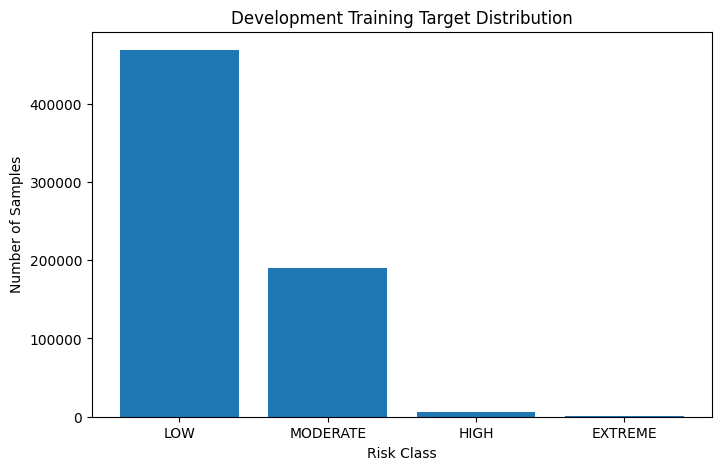

In [26]:
plt.figure(figsize=(8, 5))
plt.bar(
    class_distribution["Label"],
    class_distribution["Count"]
)

plt.xlabel("Risk Class")
plt.ylabel("Number of Samples")
plt.title("Development Training Target Distribution")

plt.show()

### Part G - Prepare Matrices

#### Create X/y

In [27]:
X_dev = (
    dev_train[FEATURE_COLUMNS]
    .astype("float32")
)

y_dev = (
    dev_train["target_risk_class"]
    .astype("int8")
)

X_val = (
    validation[FEATURE_COLUMNS]
    .astype("float32")
)

y_val = (
    validation["target_risk_class"]
    .astype("int8")
)

X_2025 = (
    temporal_test[FEATURE_COLUMNS]
    .astype("float32")
)

y_2025 = (
    temporal_test["target_risk_class"]
    .astype("int8")
)

X_digha = (
    spatial_test[FEATURE_COLUMNS]
    .astype("float32")
)

y_digha = (
    spatial_test["target_risk_class"]
    .astype("int8")
)


print("X_dev:", X_dev.shape)
print("X_val:", X_val.shape)
print("X_2025:", X_2025.shape)
print("X_spatial:", X_digha.shape)

X_dev: (665760, 41)
X_val: (166896, 41)
X_2025: (166212, 41)
X_spatial: (105144, 41)


### Part H - Baseline Model

#### Calculate Inverse Frequency Weight

In [28]:
N = len(y_dev)
K = 4

dev_class_counts = (
    y_dev
    .value_counts()
    .sort_index()
)

class_weights = {
    int(cls):
    N / (K * count)
    for cls, count
    in dev_class_counts.items()
}


print("Inverse-frequency weights:")

for cls, weight in class_weights.items():

    print(
        f"{cls} - "
        f"{class_labels[cls]}: "
        f"{weight:.4f}"
    )

Inverse-frequency weights:
0 - LOW: 0.3551
1 - MODERATE: 0.8767
2 - HIGH: 25.3681
3 - EXTREME: 270.1948


#### Create Sample Weight

In [29]:
# ============================================================
# W3 SAFETY WEIGHTS
# ============================================================

safety_weights = class_weights.copy()

# HIGH
if 2 in safety_weights:
    safety_weights[2] *= 2.0

# EXTREME
if 3 in safety_weights:
    safety_weights[3] *= 3.0


sample_weight_W3 = (
    y_dev
    .map(safety_weights)
    .to_numpy(dtype="float32")
)


print("Safety weights:")

for cls, weight in safety_weights.items():

    print(
        f"{cls} - "
        f"{class_labels[cls]}: "
        f"{weight:.4f}"
    )

Safety weights:
0 - LOW: 0.3551
1 - MODERATE: 0.8767
2 - HIGH: 50.7362
3 - EXTREME: 810.5844


#### Baseline HGBDT

In [30]:
# ============================================================
# RISK-HISTORY HGBDT
# ============================================================

baseline_model = HistGradientBoostingClassifier(

    loss="log_loss",
    learning_rate=0.03,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=1.0,
    max_bins=255,
    random_state=42
)
start = time.perf_counter()
baseline_model.fit(
    X_dev,
    y_dev,
    sample_weight=sample_weight_W3
)

training_time = (
    time.perf_counter()
    - start
)
print(
    f"Training time: "
    f"{training_time:.2f} seconds"
)

Training time: 68.60 seconds


### Part I - Evaluation Function

#### Comprehensive Evaluation Function

In [31]:
def evaluate_model(model,X,y,name):
    pred = model.predict(X)

    accuracy = accuracy_score(y,pred)

    macro_f1 = f1_score(y,pred,average="macro",zero_division=0)

    macro_precision = precision_score(y,pred,average="macro",zero_division=0)

    macro_recall = recall_score(y,pred,average="macro",zero_division=0)

    balanced_acc = balanced_accuracy_score(y,pred)

    print("=" * 70)
    print(name)
    print("=" * 70)

    print(f"Accuracy:          {accuracy:.4f}")
    print(f"Macro F1:          {macro_f1:.4f}")
    print(f"Macro Precision:   {macro_precision:.4f}")
    print(f"Macro Recall:      {macro_recall:.4f}")
    print(f"Balanced Accuracy: {balanced_acc:.4f}")

    print("\nClassification Report:")

    print(
        classification_report(
            y,
            pred,
            labels=[0, 1, 2, 3],
            target_names=[
                "LOW",
                "MODERATE",
                "HIGH",
                "EXTREME"
            ],
            zero_division=0
        )
    )

    print("Confusion Matrix:")

    display(
        pd.DataFrame(
            confusion_matrix(
                y,
                pred,
                labels=[0, 1, 2, 3]
            ),
            index=[
                "Actual LOW",
                "Actual MODERATE",
                "Actual HIGH",
                "Actual EXTREME"
            ],
            columns=[
                "Pred LOW",
                "Pred MODERATE",
                "Pred HIGH",
                "Pred EXTREME"
            ]
        )
    )

    return {
        "name": name,
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "balanced_accuracy": balanced_acc,
        "predictions": pred
    }

### Part J - Baseline Validation

#### Evaluate on 2024 Validation

In [32]:
baseline_val = evaluate_model(
    baseline_model,
    X_val,
    y_val,
    "BASELINE — 2024 VALIDATION"
)

BASELINE — 2024 VALIDATION
Accuracy:          0.9286
Macro F1:          0.6427
Macro Precision:   0.6481
Macro Recall:      0.7320
Balanced Accuracy: 0.7320

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.89      0.92     72980
        HIGH       0.31      0.91      0.46      2272
     EXTREME       0.38      0.17      0.23        65

    accuracy                           0.93    166896
   macro avg       0.65      0.73      0.64    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87668,3909,2,0
Actual MODERATE,3135,65237,4606,2
Actual HIGH,0,194,2062,16
Actual EXTREME,0,6,48,11


### Part K - Dangerous Event Metrics

#### Dangerous = HIGH + EXTREME

In [33]:
def dangerous_metrics(
    y_true,
    y_pred,
    name="Dangerous Event"
):

    actual = (
        y_true >= 2
    ).astype(int)

    predicted = (
        y_pred >= 2
    ).astype(int)

    precision = precision_score(
        actual,
        predicted,
        zero_division=0
    )

    recall = recall_score(
        actual,
        predicted,
        zero_division=0
    )

    f1 = f1_score(
        actual,
        predicted,
        zero_division=0
    )

    tn, fp, fn, tp = confusion_matrix(
        actual,
        predicted,
        labels=[0, 1]
    ).ravel()

    false_positive_rate = (
        fp / (fp + tn)
        if (fp + tn) > 0
        else 0.0
    )

    false_negative_rate = (
        fn / (fn + tp)
        if (fn + tp) > 0
        else 0.0
    )

    print("=" * 60)
    print(name)
    print("=" * 60)

    print(f"Dangerous Precision: {precision:.4f}")
    print(f"Dangerous Recall:    {recall:.4f}")
    print(f"Dangerous F1:        {f1:.4f}")
    print(f"False Positive Rate: {false_positive_rate:.4f}")
    print(f"False Negative Rate: {false_negative_rate:.4f}")

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "false_positive_rate": false_positive_rate,
        "false_negative_rate": false_negative_rate
    }

#### Evaluate Dangerous Events on Validation

In [34]:
dangerous_val = dangerous_metrics(
    y_val,
    baseline_val["predictions"],
    "BASELINE — 2024 DANGEROUS EVENT"
)

BASELINE — 2024 DANGEROUS EVENT
Dangerous Precision: 0.3167
Dangerous Recall:    0.9144
Dangerous F1:        0.4705
False Positive Rate: 0.0280
False Negative Rate: 0.0856


### Part L- WEIGHTING EXPERIMENTS
The new plan explicitly recommends:

W0 — unweighted<br>
W1 — inverse frequency<br>
W2 — capped weights<br>
W3 — safety-oriented weighting<br>

We will perform these using only 2020–2024 development data, with 2024 as validation.

#### W0 - Unweighted

In [35]:
# model_W0 = HistGradientBoostingClassifier(
#     loss="log_loss",
#     learning_rate=0.05,
#     max_iter=400,
#     max_depth=8,
#     min_samples_leaf=20,
#     l2_regularization=1.0,
#     max_bins=255,
#     random_state=42
# )

# model_W0.fit(
#     X_dev,
#     y_dev
# )

# W0_val = evaluate_model(
#     model_W0,
#     X_val,
#     y_val,
#     "W0 — UNWEIGHTED"
# )

# W0_danger = dangerous_metrics(
#     y_val,
#     W0_val["predictions"],
#     "W0 — DANGEROUS"
# )

#### W1 - Inverse Frequency

In [36]:
# model_W1 = HistGradientBoostingClassifier(
#     loss="log_loss",
#     learning_rate=0.05,
#     max_iter=400,
#     max_depth=8,
#     min_samples_leaf=20,
#     l2_regularization=1.0,
#     max_bins=255,
#     random_state=42
# )

# model_W1.fit(
#     X_dev,
#     y_dev,
#     sample_weight=sample_weight
# )

# W1_val = evaluate_model(
#     model_W1,
#     X_val,
#     y_val,
#     "W1 — INVERSE FREQUENCY"
# )

# W1_danger = dangerous_metrics(
#     y_val,
#     W1_val["predictions"],
#     "W1 — DANGEROUS"
# )

### Part M- CAPPED WEIGHTS

#### W2 - Capped Class Weights

In [37]:
# CAP = 50.0

# capped_weights = {
#     cls: min(weight, CAP)
#     for cls, weight in class_weights.items()
# }

# print("Original weights:")
# print(class_weights)

# print("\nCapped weights:")
# print(capped_weights)

#### Train W2

In [38]:
# sample_weight_W2 = (
#     y_dev
#     .map(capped_weights)
#     .to_numpy(
#         dtype="float32"
#     )
# )

# model_W2 = HistGradientBoostingClassifier(
#     loss="log_loss",
#     learning_rate=0.05,
#     max_iter=400,
#     max_depth=8,
#     min_samples_leaf=20,
#     l2_regularization=1.0,
#     max_bins=255,
#     random_state=42
# )

# model_W2.fit(
#     X_dev,
#     y_dev,
#     sample_weight=sample_weight_W2
# )

# W2_val = evaluate_model(
#     model_W2,
#     X_val,
#     y_val,
#     "W2 — CAPPED WEIGHTS"
# )

# W2_danger = dangerous_metrics(
#     y_val,
#     W2_val["predictions"],
#     "W2 — DANGEROUS"
# )

### Part N - SAFETY ORIENTED WEIGHTING

#### W3 Weights

In [39]:
# safety_weights = class_weights.copy()

# # Increase emphasis on dangerous classes.
# if 2 in safety_weights:
#     safety_weights[2] *= 2.0

# if 3 in safety_weights:
#     safety_weights[3] *= 3.0

# print(safety_weights)

#### Train W3

In [40]:
model_W3 = HistGradientBoostingClassifier(

    loss="log_loss",

    learning_rate=0.03,

    max_iter=400,

    max_depth=8,

    min_samples_leaf=20,

    l2_regularization=1.0,

    max_bins=255,

    random_state=42
)


start = time.perf_counter()

model_W3.fit(
    X_dev,
    y_dev,
    sample_weight=sample_weight_W3
)

W3_training_time = (
    time.perf_counter()
    - start
)

print(
    f"W3 training time: "
    f"{W3_training_time:.2f} seconds"
)


W3_val = evaluate_model(
    model_W3,
    X_val,
    y_val,
    "RISK-HISTORY W3 — 2024 VALIDATION"
)


W3_danger = dangerous_metrics(
    y_val,
    W3_val["predictions"],
    "RISK-HISTORY W3 — DANGEROUS"
)

W3 training time: 74.64 seconds
RISK-HISTORY W3 — 2024 VALIDATION
Accuracy:          0.9286
Macro F1:          0.6427
Macro Precision:   0.6481
Macro Recall:      0.7320
Balanced Accuracy: 0.7320

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.89      0.92     72980
        HIGH       0.31      0.91      0.46      2272
     EXTREME       0.38      0.17      0.23        65

    accuracy                           0.93    166896
   macro avg       0.65      0.73      0.64    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87668,3909,2,0
Actual MODERATE,3135,65237,4606,2
Actual HIGH,0,194,2062,16
Actual EXTREME,0,6,48,11


RISK-HISTORY W3 — DANGEROUS
Dangerous Precision: 0.3167
Dangerous Recall:    0.9144
Dangerous F1:        0.4705
False Positive Rate: 0.0280
False Negative Rate: 0.0856


#### Trying EXTREME Weight Fine-Tuning

In [41]:
# ============================================================
# PART N2 - EXTREME WEIGHT FINE-TUNING
# ============================================================

EXTREME_MULTIPLIERS = [2.0, 3.0, 4.0, 5.0]

extreme_weight_results = []
extreme_weight_models = {}

base_weights = class_weights.copy()

for multiplier in EXTREME_MULTIPLIERS:

    trial_weights = base_weights.copy()

    # Keep HIGH weighting unchanged
    trial_weights[2] *= 2.0

    # Tune EXTREME weighting
    trial_weights[3] *= multiplier

    trial_sample_weight = (
        y_dev
        .map(trial_weights)
        .to_numpy(dtype="float32")
    )

    print(
        f"\nTraining EXTREME multiplier = {multiplier}"
    )

    trial_model = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=0.03,
        max_iter=400,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        max_bins=255,
        random_state=42
    )

    start = time.perf_counter()

    trial_model.fit(
        X_dev,
        y_dev,
        sample_weight=trial_sample_weight
    )

    training_time = time.perf_counter() - start

    trial_eval = evaluate_model(
        trial_model,
        X_val,
        y_val,
        f"EXTREME WEIGHT × {multiplier}"
    )

    trial_danger = dangerous_metrics(
        y_val,
        trial_eval["predictions"],
        f"EXTREME WEIGHT × {multiplier} — DANGEROUS"
    )

    extreme_recall = recall_score(
        y_val,
        trial_eval["predictions"],
        labels=[3],
        average="macro",
        zero_division=0
    )

    extreme_weight_results.append({
        "extreme_multiplier": multiplier,
        "training_time_sec": training_time,
        "accuracy": trial_eval["accuracy"],
        "macro_f1": trial_eval["macro_f1"],
        "balanced_accuracy": trial_eval["balanced_accuracy"],
        "extreme_recall": extreme_recall,
        "dangerous_recall": trial_danger["recall"],
        "dangerous_precision": trial_danger["precision"],
        "false_alarm_rate": trial_danger["false_positive_rate"]
    })

    extreme_weight_models[multiplier] = trial_model


extreme_weight_df = (
    pd.DataFrame(extreme_weight_results)
    .sort_values(
        "extreme_recall",
        ascending=False
    )
    .reset_index(drop=True)
)

display(extreme_weight_df)


Training EXTREME multiplier = 2.0
EXTREME WEIGHT × 2.0
Accuracy:          0.9285
Macro F1:          0.6292
Macro Precision:   0.6161
Macro Recall:      0.7250
Balanced Accuracy: 0.7250

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.89      0.92     72980
        HIGH       0.31      0.91      0.46      2272
     EXTREME       0.25      0.14      0.18        65

    accuracy                           0.93    166896
   macro avg       0.62      0.73      0.63    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87652,3926,1,0
Actual MODERATE,3147,65234,4593,6
Actual HIGH,0,182,2069,21
Actual EXTREME,0,8,48,9


EXTREME WEIGHT × 2.0 — DANGEROUS
Dangerous Precision: 0.3182
Dangerous Recall:    0.9187
Dangerous F1:        0.4727
False Positive Rate: 0.0280
False Negative Rate: 0.0813

Training EXTREME multiplier = 3.0
EXTREME WEIGHT × 3.0
Accuracy:          0.9294
Macro F1:          0.6484
Macro Precision:   0.6489
Macro Recall:      0.7356
Balanced Accuracy: 0.7356

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.90      0.92     72980
        HIGH       0.31      0.90      0.47      2272
     EXTREME       0.38      0.18      0.25        65

    accuracy                           0.93    166896
   macro avg       0.65      0.74      0.65    166896
weighted avg       0.95      0.93      0.94    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87640,3938,1,0
Actual MODERATE,3144,65412,4423,1
Actual HIGH,0,198,2055,19
Actual EXTREME,0,8,45,12


EXTREME WEIGHT × 3.0 — DANGEROUS
Dangerous Precision: 0.3250
Dangerous Recall:    0.9119
Dangerous F1:        0.4793
False Positive Rate: 0.0269
False Negative Rate: 0.0881

Training EXTREME multiplier = 4.0
EXTREME WEIGHT × 4.0
Accuracy:          0.9279
Macro F1:          0.6416
Macro Precision:   0.6502
Macro Recall:      0.7329
Balanced Accuracy: 0.7329

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.89      0.92     72980
        HIGH       0.30      0.91      0.45      2272
     EXTREME       0.39      0.17      0.24        65

    accuracy                           0.93    166896
   macro avg       0.65      0.73      0.64    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87755,3822,2,0
Actual MODERATE,3181,65031,4768,0
Actual HIGH,0,181,2074,17
Actual EXTREME,0,2,52,11


EXTREME WEIGHT × 4.0 — DANGEROUS
Dangerous Precision: 0.3111
Dangerous Recall:    0.9217
Dangerous F1:        0.4652
False Positive Rate: 0.0290
False Negative Rate: 0.0783

Training EXTREME multiplier = 5.0
EXTREME WEIGHT × 5.0
Accuracy:          0.9280
Macro F1:          0.6402
Macro Precision:   0.6410
Macro Recall:      0.7320
Balanced Accuracy: 0.7320

Classification Report:
              precision    recall  f1-score   support

         LOW       0.96      0.96      0.96     91579
    MODERATE       0.94      0.89      0.92     72980
        HIGH       0.30      0.91      0.45      2272
     EXTREME       0.35      0.17      0.23        65

    accuracy                           0.93    166896
   macro avg       0.64      0.73      0.64    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87714,3863,2,0
Actual MODERATE,3195,65081,4701,3
Actual HIGH,0,189,2066,17
Actual EXTREME,0,3,51,11


EXTREME WEIGHT × 5.0 — DANGEROUS
Dangerous Precision: 0.3131
Dangerous Recall:    0.9178
Dangerous F1:        0.4669
False Positive Rate: 0.0286
False Negative Rate: 0.0822


,extreme_multiplier,training_time_sec,accuracy,macro_f1,balanced_accuracy,extreme_recall,dangerous_recall,dangerous_precision,false_alarm_rate
0,3.0,76.721098,0.929435,0.648418,0.735598,0.184615,0.911853,0.325046,0.026890
1,4.0,63.488939,0.927949,0.641612,0.732852,0.169231,0.921694,0.311092,0.028987
2,5.0,61.249313,0.927955,0.640208,0.732031,0.169231,0.917843,0.313093,0.028598
3,2.0,85.194636,0.928506,0.629184,0.725023,0.138462,0.918699,0.318216,0.027953


In [42]:
# ============================================================
# PART N3 - EXTREME PROBABILITY ANALYSIS
# ============================================================

best_weight_multiplier = (
    extreme_weight_df.iloc[0]["extreme_multiplier"]
)

best_weight_model = (
    extreme_weight_models[best_weight_multiplier]
)

val_proba_extreme = (
    best_weight_model.predict_proba(X_val)
)

p_extreme_val = val_proba_extreme[:, 3]

actual_extreme_val = (
    y_val == 3
).astype(int)

print(
    "Selected EXTREME-weight multiplier:",
    best_weight_multiplier
)

print(
    "\nActual EXTREME validation cases:",
    actual_extreme_val.sum()
)

print(
    "Mean P(EXTREME) for actual EXTREME:",
    p_extreme_val[actual_extreme_val == 1].mean()
)

print(
    "Median P(EXTREME) for actual EXTREME:",
    np.median(
        p_extreme_val[actual_extreme_val == 1]
    )
)

Selected EXTREME-weight multiplier: 3.0

Actual EXTREME validation cases: 65
Mean P(EXTREME) for actual EXTREME: 0.23301520881624485
Median P(EXTREME) for actual EXTREME: 0.11794973313564514


In [43]:
# ============================================================
# PART N4 - EXTREME CLASS THRESHOLD ANALYSIS
# ============================================================

extreme_threshold_results = []

EXTREME_THRESHOLDS = np.arange(
    0.05,
    0.61,
    0.05
)

for threshold in EXTREME_THRESHOLDS:

    pred = (
        best_weight_model
        .predict(X_val)
        .copy()
    )

    pred[
        p_extreme_val >= threshold
    ] = 3

    extreme_recall = recall_score(
        y_val,
        pred,
        labels=[3],
        average="macro",
        zero_division=0
    )

    extreme_precision = precision_score(
        y_val,
        pred,
        labels=[3],
        average="macro",
        zero_division=0
    )

    extreme_f1 = f1_score(
        y_val,
        pred,
        labels=[3],
        average="macro",
        zero_division=0
    )

    high_recall = recall_score(
        y_val,
        pred,
        labels=[2],
        average="macro",
        zero_division=0
    )

    extreme_threshold_results.append({
        "extreme_threshold": float(threshold),
        "extreme_recall": extreme_recall,
        "extreme_precision": extreme_precision,
        "extreme_f1": extreme_f1,
        "high_recall": high_recall
    })


extreme_threshold_df = pd.DataFrame(
    extreme_threshold_results
)

display(extreme_threshold_df)

,extreme_threshold,extreme_recall,extreme_precision,extreme_f1,high_recall
0,0.05,0.692308,0.155172,0.253521,0.846831
1,0.10,0.523077,0.170000,0.256604,0.865317
2,0.15,0.400000,0.191176,0.258706,0.878081
3,0.20,0.369231,0.212389,0.269663,0.882482
4,0.25,0.323077,0.230769,0.269231,0.887764
5,0.30,0.292308,0.250000,0.269504,0.892606
6,0.35,0.276923,0.290323,0.283465,0.897007
7,0.40,0.261538,0.333333,0.293103,0.899208
8,0.45,0.215385,0.378378,0.274510,0.903609
9,0.50,0.184615,0.375000,0.247423,0.904489


In [44]:
# ============================================================
# PART N5 - EXTREME -> HIGH CONFUSION ANALYSIS
# ============================================================

pred_current = best_weight_model.predict(X_val)

cm = confusion_matrix(
    y_val,
    pred_current,
    labels=[0, 1, 2, 3]
)

print("Confusion Matrix:")
display(
    pd.DataFrame(
        cm,
        index=[
            "Actual LOW",
            "Actual MODERATE",
            "Actual HIGH",
            "Actual EXTREME"
        ],
        columns=[
            "Pred LOW",
            "Pred MODERATE",
            "Pred HIGH",
            "Pred EXTREME"
        ]
    )
)

extreme_mask = y_val == 3

print(
    "\nActual EXTREME cases:",
    extreme_mask.sum()
)

print(
    "\nPredictions for actual EXTREME:"
)

print(
    pd.Series(
        pred_current[extreme_mask]
    ).value_counts()
    .sort_index()
)

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87640,3938,1,0
Actual MODERATE,3144,65412,4423,1
Actual HIGH,0,198,2055,19
Actual EXTREME,0,8,45,12



Actual EXTREME cases: 65

Predictions for actual EXTREME:
1     8
2    45
3    12
Name: count, dtype: int64


In [45]:
# ============================================================
# PART N6 - TARGETED HGBDT REFINEMENT
# ============================================================

refinement_experiments = [

    {
        "name": "refine_baseline",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "refine_depth_12",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 12,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "refine_leaf_10",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 10,
        "l2_regularization": 1.0
    },

    {
        "name": "refine_leaf_30",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0
    },

    {
        "name": "refine_l2_3",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 3.0
    },

    {
        "name": "refine_lr_002",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    }
]

refinement_results = []
refinement_models = {}

# Use the current safety weighting
refine_weights = class_weights.copy()

refine_weights[2] *= 2.0
refine_weights[3] *= 3.0

refine_sample_weight = (
    y_dev
    .map(refine_weights)
    .to_numpy(dtype="float32")
)

for params in refinement_experiments:

    print(
        "\nTraining:",
        params["name"]
    )

    model = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=params["learning_rate"],
        max_iter=params["max_iter"],
        max_depth=params["max_depth"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        max_bins=255,
        random_state=42
    )

    start = time.perf_counter()

    model.fit(
        X_dev,
        y_dev,
        sample_weight=refine_sample_weight
    )

    training_time = (
        time.perf_counter() - start
    )

    result = evaluate_model(
        model,
        X_val,
        y_val,
        params["name"]
    )

    danger = dangerous_metrics(
        y_val,
        result["predictions"],
        params["name"] + " — DANGEROUS"
    )

    high_recall = recall_score(
        y_val,
        result["predictions"],
        labels=[2],
        average="macro",
        zero_division=0
    )

    extreme_recall = recall_score(
        y_val,
        result["predictions"],
        labels=[3],
        average="macro",
        zero_division=0
    )

    refinement_results.append({
        "name": params["name"],
        "training_time_sec": training_time,
        "accuracy": result["accuracy"],
        "macro_f1": result["macro_f1"],
        "macro_precision": result["macro_precision"],
        "macro_recall": result["macro_recall"],
        "balanced_accuracy": result["balanced_accuracy"],
        "high_recall": high_recall,
        "extreme_recall": extreme_recall,
        "dangerous_recall": danger["recall"],
        "dangerous_precision": danger["precision"],
    })

    refinement_models[
        params["name"]
    ] = model


refinement_df = (
    pd.DataFrame(refinement_results)
    .sort_values(
        [
            "extreme_recall",
            "macro_f1"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(refinement_df)


Training: refine_baseline
refine_baseline
Accuracy:          0.9294
Macro F1:          0.6484
Macro Precision:   0.6489
Macro Recall:      0.7356
Balanced Accuracy: 0.7356

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.90      0.92     72980
        HIGH       0.31      0.90      0.47      2272
     EXTREME       0.38      0.18      0.25        65

    accuracy                           0.93    166896
   macro avg       0.65      0.74      0.65    166896
weighted avg       0.95      0.93      0.94    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87640,3938,1,0
Actual MODERATE,3144,65412,4423,1
Actual HIGH,0,198,2055,19
Actual EXTREME,0,8,45,12


refine_baseline — DANGEROUS
Dangerous Precision: 0.3250
Dangerous Recall:    0.9119
Dangerous F1:        0.4793
False Positive Rate: 0.0269
False Negative Rate: 0.0881

Training: refine_depth_12
refine_depth_12
Accuracy:          0.9294
Macro F1:          0.6490
Macro Precision:   0.6385
Macro Recall:      0.7395
Balanced Accuracy: 0.7395

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.90      0.92     72980
        HIGH       0.31      0.90      0.47      2272
     EXTREME       0.33      0.20      0.25        65

    accuracy                           0.93    166896
   macro avg       0.64      0.74      0.65    166896
weighted avg       0.95      0.93      0.94    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87645,3933,1,0
Actual MODERATE,3144,65397,4434,5
Actual HIGH,0,195,2056,21
Actual EXTREME,0,7,45,13


refine_depth_12 — DANGEROUS
Dangerous Precision: 0.3247
Dangerous Recall:    0.9136
Dangerous F1:        0.4791
False Positive Rate: 0.0270
False Negative Rate: 0.0864

Training: refine_leaf_10
refine_leaf_10
Accuracy:          0.9273
Macro F1:          0.6503
Macro Precision:   0.6364
Macro Recall:      0.7486
Balanced Accuracy: 0.7486

Classification Report:
              precision    recall  f1-score   support

         LOW       0.96      0.96      0.96     91579
    MODERATE       0.94      0.89      0.91     72980
        HIGH       0.30      0.92      0.45      2272
     EXTREME       0.34      0.23      0.28        65

    accuracy                           0.93    166896
   macro avg       0.64      0.75      0.65    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


...

,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87678,3899,2,0
Actual MODERATE,3151,65299,4528,2
Actual HIGH,0,199,2052,21
Actual EXTREME,0,8,41,16


refine_l2_3 — DANGEROUS
Dangerous Precision: 0.3197
Dangerous Recall:    0.9114
Dangerous F1:        0.4734
False Positive Rate: 0.0275
False Negative Rate: 0.0886

Training: refine_lr_002
refine_lr_002
Accuracy:          0.9286
Macro F1:          0.6609
Macro Precision:   0.6558
Macro Recall:      0.7506
Balanced Accuracy: 0.7506

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     91579
    MODERATE       0.94      0.89      0.92     72980
        HIGH       0.31      0.90      0.46      2272
     EXTREME       0.41      0.25      0.31        65

    accuracy                           0.93    166896
   macro avg       0.66      0.75      0.66    166896
weighted avg       0.95      0.93      0.93    166896

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,87704,3873,2,0
Actual MODERATE,3166,65203,4610,1
Actual HIGH,0,194,2056,22
Actual EXTREME,0,7,42,16


refine_lr_002 — DANGEROUS
Dangerous Precision: 0.3165
Dangerous Recall:    0.9140
Dangerous F1:        0.4702
False Positive Rate: 0.0280
False Negative Rate: 0.0860


,name,training_time_sec,accuracy,macro_f1,macro_precision,macro_recall,balanced_accuracy,high_recall,extreme_recall,dangerous_recall,dangerous_precision
0,refine_l2_3,64.304100,0.928992,0.661908,0.656559,0.750369,0.750369,0.903169,0.246154,0.911425,0.319724
1,refine_lr_002,89.559097,0.928596,0.660900,0.655754,0.750552,0.750552,0.904930,0.246154,0.913992,0.316491
2,refine_leaf_30,54.359456,0.927092,0.654013,0.649568,0.748918,0.748918,0.917694,0.230769,0.928541,0.307322
3,refine_leaf_10,55.839634,0.927254,0.650349,0.636402,0.748585,0.748585,0.915933,0.230769,0.925973,0.308043
4,refine_depth_12,83.802623,0.929387,0.648953,0.638450,0.739517,0.739517,0.904930,0.200000,0.913564,0.324715
5,refine_baseline,71.645786,0.929435,0.648418,0.648945,0.735598,0.735598,0.904489,0.184615,0.911853,0.325046


### Part O - COMPARE WEIGHTING STRATEGIES

#### Weighting Scorecard

In [46]:
# weighting_results = pd.DataFrame({

#     "Model": [
#         "W0 Unweighted",
#         "W1 Inverse Frequency",
#         "W2 Capped",
#         "W3 Safety"
#     ],

#     "Accuracy": [
#         W0_val["accuracy"],
#         W1_val["accuracy"],
#         W2_val["accuracy"],
#         W3_val["accuracy"]
#     ],

#     "Macro F1": [
#         W0_val["macro_f1"],
#         W1_val["macro_f1"],
#         W2_val["macro_f1"],
#         W3_val["macro_f1"]
#     ],

#     "Macro Precision": [
#         W0_val["macro_precision"],
#         W1_val["macro_precision"],
#         W2_val["macro_precision"],
#         W3_val["macro_precision"]
#     ],

#     "Macro Recall": [
#         W0_val["macro_recall"],
#         W1_val["macro_recall"],
#         W2_val["macro_recall"],
#         W3_val["macro_recall"]
#     ],

#     "Balanced Accuracy": [
#         W0_val["balanced_accuracy"],
#         W1_val["balanced_accuracy"],
#         W2_val["balanced_accuracy"],
#         W3_val["balanced_accuracy"]
#     ],

#     "Dangerous Recall": [
#         W0_danger["recall"],
#         W1_danger["recall"],
#         W2_danger["recall"],
#         W3_danger["recall"]
#     ],

#     "Dangerous Precision": [
#         W0_danger["precision"],
#         W1_danger["precision"],
#         W2_danger["precision"],
#         W3_danger["precision"]
#     ]
# })

# display(
#     weighting_results.sort_values(
#         "Macro F1",
#         ascending=False
#     )
# )

### Part P - HYPERPARAMETER TUNING

#### Hyperparameter Experiment

In [47]:
# ============================================================
# RISK-HISTORY HGBDT HYPERPARAMETER TUNING
# ============================================================

experiments = [

    {
        "name": "risk_history_baseline",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 8,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_lr_002",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 8,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_lr_003_600",
        "learning_rate": 0.03,
        "max_iter": 600,
        "max_depth": 8,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_depth_6",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 6,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_depth_10",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_leaf_30",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 8,
        "min_samples_leaf": 30,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_leaf_50",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 8,
        "min_samples_leaf": 50,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_l2_3",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 8,
        "min_samples_leaf": 30,
        "l2_regularization": 3.0
    },

    {
        "name": "risk_history_deep_safety",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 8,
        "min_samples_leaf": 15,
        "l2_regularization": 1.0
    },

    {
        "name": "risk_history_generalization",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 7,
        "min_samples_leaf": 40,
        "l2_regularization": 3.0
    }
]

tuning_results = []
tuning_models = {}

for params in experiments:

    print(
        "\nTraining:",
        params["name"]
    )

    model = HistGradientBoostingClassifier(

        loss="log_loss",

        learning_rate=params["learning_rate"],

        max_iter=params["max_iter"],

        max_depth=params["max_depth"],

        min_samples_leaf=params["min_samples_leaf"],

        l2_regularization=params["l2_regularization"],

        max_bins=255,

        random_state=42
    )


    start = time.perf_counter()


    model.fit(
        X_dev,
        y_dev,
        sample_weight=sample_weight_W3
    )


    train_time = (
        time.perf_counter()
        - start
    )


    pred = model.predict(X_val)


    dangerous_true = (
        y_val >= 2
    ).astype(int)

    dangerous_pred = (
        pred >= 2
    ).astype(int)


    result = {

        "name":
            params["name"],

        "training_time_sec":
            train_time,

        "accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "macro_f1":
            f1_score(
                y_val,
                pred,
                average="macro",
                zero_division=0
            ),

        "macro_precision":
            precision_score(
                y_val,
                pred,
                average="macro",
                zero_division=0
            ),

        "macro_recall":
            recall_score(
                y_val,
                pred,
                average="macro",
                zero_division=0
            ),

        "balanced_accuracy":
            balanced_accuracy_score(
                y_val,
                pred
            ),

        "high_recall":
            recall_score(
                y_val,
                pred,
                labels=[2],
                average="macro",
                zero_division=0
            ),

        "extreme_recall":
            recall_score(
                y_val,
                pred,
                labels=[3],
                average="macro",
                zero_division=0
            ),

        "dangerous_recall":
            recall_score(
                dangerous_true,
                dangerous_pred,
                zero_division=0
            ),

        "dangerous_precision":
            precision_score(
                dangerous_true,
                dangerous_pred,
                zero_division=0
            )
    }


    tuning_results.append(result)

    tuning_models[
        params["name"]
    ] = model


tuning_results_df = (
    pd.DataFrame(tuning_results)
)


display(
    tuning_results_df.sort_values(
        [
            "macro_f1",
            "dangerous_recall",
            "high_recall",
            "dangerous_precision"
        ],
        ascending=False
    ).reset_index(drop=True)
)


Training: risk_history_baseline

Training: risk_history_lr_002

Training: risk_history_lr_003_600

Training: risk_history_depth_6

Training: risk_history_depth_10

Training: risk_history_leaf_30

Training: risk_history_leaf_50

Training: risk_history_l2_3

Training: risk_history_deep_safety

Training: risk_history_generalization


,name,training_time_sec,accuracy,macro_f1,macro_precision,macro_recall,balanced_accuracy,high_recall,extreme_recall,dangerous_recall,dangerous_precision
0,risk_history_l2_3,63.223120,0.928530,0.660756,0.666911,0.748077,0.748077,0.910651,0.230769,0.917843,0.316465
1,risk_history_lr_002,86.312025,0.927428,0.652502,0.654288,0.745263,0.745263,0.917694,0.215385,0.926401,0.308492
2,risk_history_leaf_30,64.405524,0.928153,0.649515,0.650968,0.740565,0.740565,0.912412,0.200000,0.920411,0.313100
3,risk_history_deep_safety,52.090832,0.926859,0.648816,0.644763,0.744486,0.744486,0.915933,0.215385,0.923834,0.303103
4,risk_history_depth_10,72.469879,0.929435,0.648418,0.648945,0.735598,0.735598,0.904489,0.184615,0.911853,0.325046
5,risk_history_baseline,72.838354,0.928590,0.642717,0.648117,0.731999,0.731999,0.907570,0.169231,0.914420,0.316733
6,risk_history_lr_003_600,64.244963,0.928590,0.642717,0.648117,0.731999,0.731999,0.907570,0.169231,0.914420,0.316733
7,risk_history_depth_6,50.739491,0.923713,0.635869,0.618311,0.743166,0.743166,0.917694,0.215385,0.931108,0.285789
8,risk_history_generalization,97.081879,0.927140,0.634589,0.623236,0.732045,0.732045,0.911092,0.169231,0.922122,0.308033
9,risk_history_leaf_50,61.957531,0.928099,0.633307,0.625740,0.728477,0.728477,0.910211,0.153846,0.918271,0.311873


In [48]:
# ============================================================
# N6 → EXISTING MODEL SELECTION INTEGRATION
# ============================================================

# N6 refinement results → existing tuning results
n6_selection_results = refinement_df.copy()

# Add N6 models to the existing model dictionary
tuning_models.update(refinement_models)

# Add N6 results to the existing tuning results
tuning_results_df = pd.concat(
    [
        tuning_results_df,
        n6_selection_results
    ],
    ignore_index=True
)

# ------------------------------------------------------------
# Add N6 hyperparameter configurations to `experiments`
# so the existing FINAL MODEL RETRAINING cell can use them.
# ------------------------------------------------------------

n6_experiments = [
    {
        "name": "refine_l2_3",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 3
    },
    {
        "name": "refine_lr_002",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 1
    },
    {
        "name": "refine_leaf_30",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 30,
        "l2_regularization": 1
    },
    {
        "name": "refine_leaf_10",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 10,
        "l2_regularization": 1
    },
    {
        "name": "refine_depth_12",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 12,
        "min_samples_leaf": 20,
        "l2_regularization": 1
    },
    {
        "name": "refine_baseline",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 10,
        "min_samples_leaf": 20,
        "l2_regularization": 1
    }
]

# Prevent duplicate entries if the cell is accidentally rerun
existing_experiment_names = {
    x["name"] for x in experiments
}

for params in n6_experiments:
    if params["name"] not in existing_experiment_names:
        experiments.append(params)

print("✓ N6 results integrated into existing model selection.")
print(f"Total candidate models: {len(tuning_results_df)}")
print(f"Total experiment configurations: {len(experiments)}")

✓ N6 results integrated into existing model selection.
Total candidate models: 16
Total experiment configurations: 16


## Part N7 - AGGRESSIVE HIGH ↔ EXTREME TEMPORAL RECOVERY

The previous model already detected the **DANGEROUS = HIGH + EXTREME** group well, but it was collapsing many EXTREME observations into HIGH.

This stage therefore targets only the severity boundary:

**HIGH ↔ EXTREME**

Rules:
- 2024 is the only tuning/selection period.
- 2025 and Digha remain untouched until final evaluation.
- LOW/MODERATE predictions are never promoted by this stage.
- Only an existing dangerous prediction (HIGH/EXTREME) can be changed from HIGH → EXTREME.
- Therefore standard Dangerous Recall/Precision and False Alarm Rate are structurally preserved.
- The existing operational dangerous threshold `P(HIGH)+P(EXTREME)` is not changed by this stage.


In [49]:
# ============================================================
# PART N7 - AGGRESSIVE HIGH / EXTREME TEMPORAL RECOVERY
# ============================================================
# Goal: recover EXTREME cases that the multiclass HGBDT currently
# labels HIGH, while preserving the dangerous/non-dangerous boundary.
#
# IMPORTANT:
#   * 2024 validation ONLY is used for all decisions here.
#   * 2025 and Digha are NOT used for tuning.
#   * The severity rule can only convert HIGH -> EXTREME.
#   * LOW/MODERATE predictions are never promoted.
#   * Thus standard dangerous metrics remain unchanged by design.

MIN_N7_DANGEROUS_RECALL = 0.90
MIN_N7_HIGH_RECALL = 0.85
MIN_N7_MACRO_F1 = 0.62

# Candidate base models: keep the strongest validation candidates.
base_pool = (
    tuning_results_df[
        tuning_results_df["dangerous_recall"] >= MIN_N7_DANGEROUS_RECALL
    ]
    .sort_values(
        ["macro_f1", "dangerous_recall", "balanced_accuracy"],
        ascending=False
    )
    .drop_duplicates("name")
    .head(6)["name"]
    .tolist()
)

if not base_pool:
    base_pool = (
        tuning_results_df
        .sort_values("macro_f1", ascending=False)
        .drop_duplicates("name")
        .head(6)["name"]
        .tolist()
    )

print("N7 base candidates:")
print(base_pool)

# ------------------------------------------------------------
# Strategy A: directly lower the EXTREME probability boundary
# ------------------------------------------------------------
n7_results = []

for base_name in base_pool:

    base_model = tuning_models[base_name]

    base_pred = base_model.predict(X_val)
    base_proba = base_model.predict_proba(X_val)
    base_p_extreme = base_proba[:, 3]

    # Only evaluate severity decisions inside the already-dangerous set.
    dangerous_gate = base_pred >= 2

    for threshold in np.arange(0.05, 0.501, 0.01):

        pred = base_pred.copy()

        promote = (
            dangerous_gate
            &
            (base_p_extreme >= threshold)
            &
            (base_pred == 2)
        )

        pred[promote] = 3

        n7_results.append({
            "method": "base_p_extreme_threshold",
            "base_model": base_name,
            "specialist": "none",
            "threshold": float(threshold),
            "accuracy": accuracy_score(y_val, pred),
            "macro_f1": f1_score(
                y_val, pred, average="macro", zero_division=0
            ),
            "macro_precision": precision_score(
                y_val, pred, average="macro", zero_division=0
            ),
            "macro_recall": recall_score(
                y_val, pred, average="macro", zero_division=0
            ),
            "balanced_accuracy": balanced_accuracy_score(y_val, pred),
            "high_recall": recall_score(
                y_val, pred, labels=[2],
                average="macro", zero_division=0
            ),
            "extreme_recall": recall_score(
                y_val, pred, labels=[3],
                average="macro", zero_division=0
            ),
            "dangerous_recall": recall_score(
                (y_val >= 2).astype(int),
                (pred >= 2).astype(int),
                zero_division=0
            ),
            "dangerous_precision": precision_score(
                (y_val >= 2).astype(int),
                (pred >= 2).astype(int),
                zero_division=0
            ),
            "false_alarm_rate": (
                (
                    ((pred >= 2).astype(int) == 1)
                    &
                    ((y_val >= 2).astype(int) == 0)
                ).sum()
                /
                max(((y_val >= 2).astype(int) == 0).sum(), 1)
            )
        })

# ------------------------------------------------------------
# Strategy B: dedicated HIGH-vs-EXTREME specialist
# ------------------------------------------------------------
dangerous_train_mask = y_dev >= 2
X_dev_danger = X_dev.loc[dangerous_train_mask].copy()
y_dev_danger = y_dev.loc[dangerous_train_mask].copy()

# Binary target: HIGH=0, EXTREME=1
y_dev_severity = (y_dev_danger == 3).astype("int8")

specialist_configs = [
    {
        "name": "sev_d6_leaf10_l2_1_x3",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 6,
        "min_samples_leaf": 10,
        "l2_regularization": 1.0,
        "extreme_multiplier": 3.0
    },
    {
        "name": "sev_d8_leaf10_l2_1_x3",
        "learning_rate": 0.03,
        "max_iter": 400,
        "max_depth": 8,
        "min_samples_leaf": 10,
        "l2_regularization": 1.0,
        "extreme_multiplier": 3.0
    },
    {
        "name": "sev_d8_leaf10_l2_3_x4",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 8,
        "min_samples_leaf": 10,
        "l2_regularization": 3.0,
        "extreme_multiplier": 4.0
    },
    {
        "name": "sev_d10_leaf10_l2_3_x4",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 10,
        "min_samples_leaf": 10,
        "l2_regularization": 3.0,
        "extreme_multiplier": 4.0
    },
    {
        "name": "sev_d8_leaf5_l2_3_x6",
        "learning_rate": 0.02,
        "max_iter": 600,
        "max_depth": 8,
        "min_samples_leaf": 5,
        "l2_regularization": 3.0,
        "extreme_multiplier": 6.0
    }
]

n7_specialist_models = {}

for cfg in specialist_configs:

    print("\nTraining specialist:", cfg["name"])

    severity_weights = np.where(
        y_dev_severity.to_numpy() == 1,
        cfg["extreme_multiplier"],
        1.0
    ).astype("float32")

    specialist = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=cfg["learning_rate"],
        max_iter=cfg["max_iter"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        l2_regularization=cfg["l2_regularization"],
        max_bins=255,
        early_stopping=False,
        random_state=42
    )

    specialist.fit(
        X_dev_danger,
        y_dev_severity,
        sample_weight=severity_weights
    )

    n7_specialist_models[cfg["name"]] = specialist

    specialist_p_extreme = specialist.predict_proba(X_val)[:, 1]

    for base_name in base_pool:

        base_model = tuning_models[base_name]
        base_pred = base_model.predict(X_val)
        dangerous_gate = base_pred >= 2

        for threshold in np.arange(0.10, 0.901, 0.02):

            pred = base_pred.copy()

            promote = (
                dangerous_gate
                &
                (base_pred == 2)
                &
                (specialist_p_extreme >= threshold)
            )

            pred[promote] = 3

            danger_true = (y_val >= 2).astype(int)
            danger_pred = (pred >= 2).astype(int)

            n7_results.append({
                "method": "high_extreme_specialist",
                "base_model": base_name,
                "specialist": cfg["name"],
                "threshold": float(threshold),
                "accuracy": accuracy_score(y_val, pred),
                "macro_f1": f1_score(
                    y_val, pred, average="macro", zero_division=0
                ),
                "macro_precision": precision_score(
                    y_val, pred, average="macro", zero_division=0
                ),
                "macro_recall": recall_score(
                    y_val, pred, average="macro", zero_division=0
                ),
                "balanced_accuracy": balanced_accuracy_score(y_val, pred),
                "high_recall": recall_score(
                    y_val, pred, labels=[2],
                    average="macro", zero_division=0
                ),
                "extreme_recall": recall_score(
                    y_val, pred, labels=[3],
                    average="macro", zero_division=0
                ),
                "dangerous_recall": recall_score(
                    danger_true, danger_pred, zero_division=0
                ),
                "dangerous_precision": precision_score(
                    danger_true, danger_pred, zero_division=0
                ),
                "false_alarm_rate": (
                    (
                        (danger_pred == 1)
                        &
                        (danger_true == 0)
                    ).sum()
                    /
                    max((danger_true == 0).sum(), 1)
                )
            })

n7_results_df = pd.DataFrame(n7_results)

class _N7PredictionAdapter:
    def __init__(self, predictions):
        self._predictions = np.asarray(predictions)

    def predict(self, X):
        return self._predictions


# ------------------------------------------------------------
# Final N7 selection:
# 1. Dangerous Recall >= 90%
# 2. HIGH Recall >= 80%
# 3. Macro F1 >= 0.60
# 4. Maximize EXTREME Recall
# 5. Then Macro F1 / Balanced Accuracy / Dangerous Precision
# ------------------------------------------------------------
n7_eligible = n7_results_df[
    (n7_results_df["dangerous_recall"] >= MIN_N7_DANGEROUS_RECALL)
    &
    (n7_results_df["high_recall"] >= MIN_N7_HIGH_RECALL)
    &
    (n7_results_df["macro_f1"] >= MIN_N7_MACRO_F1)
].copy()

if len(n7_eligible) == 0:
    print(
        "N7 strict constraints produced no candidate. "
        "Relaxing to Macro F1 >= 0.60 and HIGH Recall >= 80%, "
        "while keeping Dangerous Recall >= 90%."
    )
    n7_eligible = n7_results_df[
        (n7_results_df["dangerous_recall"] >= 0.90)
        &
        (n7_results_df["high_recall"] >= 0.80)
        &
        (n7_results_df["macro_f1"] >= 0.60)
    ].copy()

if len(n7_eligible) == 0:
    n7_eligible = n7_results_df[
        n7_results_df["dangerous_recall"] >= 0.90
    ].copy()

if len(n7_eligible) == 0:
    raise RuntimeError("N7 could not produce a safe candidate.")

n7_best = (
    n7_eligible
    .sort_values(
        [
            "extreme_recall",
            "macro_f1",
            "balanced_accuracy",
            "dangerous_precision",
            "high_recall"
        ],
        ascending=False
    )
    .iloc[0]
)

N7_METHOD = str(n7_best["method"])
N7_BASE_MODEL = str(n7_best["base_model"])
N7_SPECIALIST_NAME = str(n7_best["specialist"])
N7_THRESHOLD = float(n7_best["threshold"])

best_model_name = N7_BASE_MODEL
best_development_model = tuning_models[best_model_name]

print("\n" + "=" * 70)
print("N7 SELECTED SEVERITY STRATEGY")
print("=" * 70)
print(n7_best.to_frame("value"))

print("\nBase model:", N7_BASE_MODEL)
print("Severity method:", N7_METHOD)
print("Specialist:", N7_SPECIALIST_NAME)
print("Severity threshold:", N7_THRESHOLD)

# Explicit proof that the severity stage preserves dangerous membership
n7_base_pred = best_development_model.predict(X_val)

if N7_METHOD == "base_p_extreme_threshold":
    n7_selected_p = best_development_model.predict_proba(X_val)[:, 3]
    n7_selected_pred = n7_base_pred.copy()
    n7_selected_pred[
        (n7_base_pred == 2) &
        (n7_selected_p >= N7_THRESHOLD)
    ] = 3
else:
    n7_selected_specialist = n7_specialist_models[N7_SPECIALIST_NAME]
    n7_selected_p = n7_selected_specialist.predict_proba(X_val)[:, 1]
    n7_selected_pred = n7_base_pred.copy()
    n7_selected_pred[
        (n7_base_pred == 2) &
        (n7_selected_p >= N7_THRESHOLD)
    ] = 3

assert np.array_equal(
    (n7_base_pred >= 2),
    (n7_selected_pred >= 2)
)

print("\n✓ Dangerous membership is unchanged by N7.")
print(
    "Validation EXTREME recall after N7:",
    recall_score(
        y_val,
        n7_selected_pred,
        labels=[3],
        average="macro",
        zero_division=0
    )
)
print(
    "Validation HIGH recall after N7:",
    recall_score(
        y_val,
        n7_selected_pred,
        labels=[2],
        average="macro",
        zero_division=0
    )
)


N7 base candidates:
['refine_l2_3', 'refine_lr_002', 'risk_history_l2_3', 'refine_leaf_30', 'risk_history_lr_002', 'refine_leaf_10']

Training specialist: sev_d6_leaf10_l2_1_x3

Training specialist: sev_d8_leaf10_l2_1_x3

Training specialist: sev_d8_leaf10_l2_3_x4

Training specialist: sev_d10_leaf10_l2_3_x4

Training specialist: sev_d8_leaf5_l2_3_x6

N7 SELECTED SEVERITY STRATEGY
                                        value
method               base_p_extreme_threshold
base_model                     refine_leaf_10
specialist                               none
threshold                                0.07
accuracy                             0.926613
macro_f1                             0.638928
macro_precision                      0.586533
macro_recall                         0.848894
balanced_accuracy                    0.848894
high_recall                          0.855634
extreme_recall                       0.692308
dangerous_recall                     0.925973
dangerous_precisio

In [50]:
display(
    tuning_results_df.sort_values(
        [
            "macro_f1",
            "dangerous_recall",
            "high_recall",
            "dangerous_precision"
        ],
        ascending=False
    ).reset_index(drop=True)
)

,name,training_time_sec,accuracy,macro_f1,macro_precision,macro_recall,balanced_accuracy,high_recall,extreme_recall,dangerous_recall,dangerous_precision
0,refine_l2_3,64.304100,0.928992,0.661908,0.656559,0.750369,0.750369,0.903169,0.246154,0.911425,0.319724
1,refine_lr_002,89.559097,0.928596,0.660900,0.655754,0.750552,0.750552,0.904930,0.246154,0.913992,0.316491
2,risk_history_l2_3,63.223120,0.928530,0.660756,0.666911,0.748077,0.748077,0.910651,0.230769,0.917843,0.316465
3,refine_leaf_30,54.359456,0.927092,0.654013,0.649568,0.748918,0.748918,0.917694,0.230769,0.928541,0.307322
4,risk_history_lr_002,86.312025,0.927428,0.652502,0.654288,0.745263,0.745263,0.917694,0.215385,0.926401,0.308492
5,refine_leaf_10,55.839634,0.927254,0.650349,0.636402,0.748585,0.748585,0.915933,0.230769,0.925973,0.308043
6,risk_history_leaf_30,64.405524,0.928153,0.649515,0.650968,0.740565,0.740565,0.912412,0.200000,0.920411,0.313100
7,refine_depth_12,83.802623,0.929387,0.648953,0.638450,0.739517,0.739517,0.904930,0.200000,0.913564,0.324715
8,risk_history_deep_safety,52.090832,0.926859,0.648816,0.644763,0.744486,0.744486,0.915933,0.215385,0.923834,0.303103
9,risk_history_depth_10,72.469879,0.929435,0.648418,0.648945,0.735598,0.735598,0.904489,0.184615,0.911853,0.325046


### Part Q - SELECT DEVELOPMENT MODEL

#### Select Best Model

In [51]:
# ============================================================
# PART Q - PRELIMINARY DEVELOPMENT MODEL SELECTION
# ============================================================
# This selection uses ONLY the 2024 validation period.
# N7 below performs the final HIGH-vs-EXTREME refinement.

MIN_DANGEROUS_RECALL = 0.90

selection_df = tuning_results_df.copy()

eligible = selection_df[
    selection_df["dangerous_recall"] >= MIN_DANGEROUS_RECALL
].copy()

if len(eligible) == 0:
    eligible = selection_df.copy()

selection_df = (
    eligible
    .sort_values(
        [
            "macro_f1",
            "dangerous_recall",
            "dangerous_precision",
            "balanced_accuracy"
        ],
        ascending=False
    )
    .reset_index(drop=True)
)

display(selection_df)

best_model_name = selection_df.iloc[0]["name"]
best_development_model = tuning_models[best_model_name]

print("Preliminary selected development model:", best_model_name)


,name,training_time_sec,accuracy,macro_f1,macro_precision,macro_recall,balanced_accuracy,high_recall,extreme_recall,dangerous_recall,dangerous_precision
0,refine_l2_3,64.304100,0.928992,0.661908,0.656559,0.750369,0.750369,0.903169,0.246154,0.911425,0.319724
1,refine_lr_002,89.559097,0.928596,0.660900,0.655754,0.750552,0.750552,0.904930,0.246154,0.913992,0.316491
2,risk_history_l2_3,63.223120,0.928530,0.660756,0.666911,0.748077,0.748077,0.910651,0.230769,0.917843,0.316465
3,refine_leaf_30,54.359456,0.927092,0.654013,0.649568,0.748918,0.748918,0.917694,0.230769,0.928541,0.307322
4,risk_history_lr_002,86.312025,0.927428,0.652502,0.654288,0.745263,0.745263,0.917694,0.215385,0.926401,0.308492
5,refine_leaf_10,55.839634,0.927254,0.650349,0.636402,0.748585,0.748585,0.915933,0.230769,0.925973,0.308043
6,risk_history_leaf_30,64.405524,0.928153,0.649515,0.650968,0.740565,0.740565,0.912412,0.200000,0.920411,0.313100
7,refine_depth_12,83.802623,0.929387,0.648953,0.638450,0.739517,0.739517,0.904930,0.200000,0.913564,0.324715
8,risk_history_deep_safety,52.090832,0.926859,0.648816,0.644763,0.744486,0.744486,0.915933,0.215385,0.923834,0.303103
9,risk_history_depth_10,72.469879,0.929435,0.648418,0.648945,0.735598,0.735598,0.904489,0.184615,0.911853,0.325046


Preliminary selected development model: refine_l2_3


### Part Q2 - Optimize Dangerous Event Warning Threshold

In [52]:
# ============================================================
# DANGEROUS EVENT THRESHOLD OPTIMIZATION
# ============================================================
# IMPORTANT: N7 severity refinement does NOT change this calculation.
# Dangerous = P(HIGH) + P(EXTREME) from the base HGBDT.


val_proba = (best_development_model.predict_proba(X_val))

p_dangerous_val = (val_proba[:, 2] + val_proba[:, 3])

y_val_dangerous = (y_val >= 2).astype(int)

threshold_results = []

thresholds = np.arange(0.01,0.51,0.01)

for threshold in thresholds:
    predicted_dangerous = (p_dangerous_val >= threshold).astype(int)
    recall = recall_score(y_val_dangerous,predicted_dangerous,zero_division=0)
    
    precision = precision_score(y_val_dangerous,predicted_dangerous,zero_division=0)

    false_alarm_rate = (((predicted_dangerous == 1) & (y_val_dangerous == 0)).sum() /max((y_val_dangerous == 0).sum(),1))

    threshold_results.append({
        "threshold":
            float(threshold),
        "dangerous_recall":
            recall,
        "dangerous_precision":
            precision,
        "false_alarm_rate":
            false_alarm_rate
    })

threshold_df = pd.DataFrame(
    threshold_results
)

display(threshold_df)

,threshold,dangerous_recall,dangerous_precision,false_alarm_rate
0,0.01,1.000000,0.057271,0.233770
1,0.02,0.997433,0.081242,0.160192
2,0.03,0.996577,0.098770,0.129139
3,0.04,0.995721,0.112917,0.111091
4,0.05,0.994009,0.124185,0.099557
5,0.06,0.991014,0.133834,0.091086
6,0.07,0.988447,0.142285,0.084620
7,0.08,0.987591,0.150417,0.079218
8,0.09,0.986307,0.158082,0.074599
9,0.10,0.985451,0.164924,0.070862


### Part Q3 - Select Operational Dangerous Threshold

In [53]:
# ============================================================
# SELECT OPERATIONAL DANGEROUS THRESHOLD
# ============================================================

MIN_DANGEROUS_RECALL = 0.90


eligible_thresholds = (
    threshold_df[
        threshold_df[
            "dangerous_recall"
        ] >= MIN_DANGEROUS_RECALL
    ]
    .copy()
)


if len(eligible_thresholds) > 0:

    best_threshold_row = (
        eligible_thresholds
        .sort_values(
            [
                "dangerous_precision",
                "false_alarm_rate"
            ],
            ascending=[
                False,
                True
            ]
        )
        .iloc[0]
    )

else:

    best_threshold_row = (
        threshold_df
        .sort_values(
            [
                "dangerous_recall",
                "dangerous_precision"
            ],
            ascending=False
        )
        .iloc[0]
    )


DANGEROUS_THRESHOLD = float(
    best_threshold_row[
        "threshold"
    ]
)


print(
    f"Selected threshold: "
    f"{DANGEROUS_THRESHOLD:.2f}"
)

print(
    f"Validation dangerous recall: "
    f"{best_threshold_row['dangerous_recall']:.4f}"
)

print(
    f"Validation dangerous precision: "
    f"{best_threshold_row['dangerous_precision']:.4f}"
)

print(
    f"Validation false alarm rate: "
    f"{best_threshold_row['false_alarm_rate']:.4f}"
)

Selected threshold: 0.50
Validation dangerous recall: 0.9123
Validation dangerous precision: 0.3197
Validation false alarm rate: 0.0276


### Part R - FEATURE ABLATION

#### Define Feature Groups

In [54]:
NO_GEOGRAPHY = [
    "latitude",
    "longitude"
]


NO_PHYSICS = [
    "wave_steepness",
    "gust_excess_kts",
    "gust_to_wind_ratio",
    "gust_above_gale"
]


NO_CROSS_SEA = [
    "cross_sea_angle"
]


NO_TEMPORAL = [
    "month_sin",
    "month_cos",
    "hour_sin"
]


NO_RISK_HISTORY = (
    RISK_HISTORY_FEATURES
)

#### Feature Ablation Experiment

In [55]:
feature_sets = {

    "Full 41":
        FEATURE_COLUMNS,

    "No Geography":
        [
            f for f in FEATURE_COLUMNS
            if f not in NO_GEOGRAPHY
        ],

    "No Physics":
        [
            f for f in FEATURE_COLUMNS
            if f not in NO_PHYSICS
        ],

    "No Cross-Sea":
        [
            f for f in FEATURE_COLUMNS
            if f not in NO_CROSS_SEA
        ],

    "No Temporal":
        [
            f for f in FEATURE_COLUMNS
            if f not in NO_TEMPORAL
        ],

    "No Risk History":
        [
            f for f in FEATURE_COLUMNS
            if f not in NO_RISK_HISTORY
        ]
}


ablation_results = []


for name, features in feature_sets.items():

    print(
        "\nTraining:",
        name
    )


    model = HistGradientBoostingClassifier(

        loss="log_loss",

        learning_rate=0.03,

        max_iter=400,

        max_depth=8,

        min_samples_leaf=20,

        l2_regularization=1.0,

        max_bins=255,

        random_state=42
    )


    model.fit(
        X_dev[features],
        y_dev,
        sample_weight=sample_weight_W3
    )


    pred = model.predict(
        X_val[features]
    )


    dangerous_true = (
        y_val >= 2
    ).astype(int)

    dangerous_pred = (
        pred >= 2
    ).astype(int)


    ablation_results.append({

        "Feature Set":
            name,

        "Features":
            len(features),

        "Accuracy":
            accuracy_score(
                y_val,
                pred
            ),

        "Macro F1":
            f1_score(
                y_val,
                pred,
                average="macro",
                zero_division=0
            ),

        "Balanced Accuracy":
            balanced_accuracy_score(
                y_val,
                pred
            ),

        "HIGH Recall":
            recall_score(
                y_val,
                pred,
                labels=[2],
                average="macro",
                zero_division=0
            ),
        "EXTREME Recall":
            recall_score(
                y_val,
                pred,
                labels = [3],
                average = "macro",
                zero_division = 0
            ),

        "Dangerous Recall":
            recall_score(
                dangerous_true,
                dangerous_pred,
                zero_division=0
            ),

        "Dangerous Precision":
            precision_score(
                dangerous_true,
                dangerous_pred,
                zero_division=0
            )
    })


ablation_df = pd.DataFrame(
    ablation_results
)


display(
    ablation_df.sort_values(
        "Macro F1",
        ascending=False
    )
)


Training: Full 41

Training: No Geography

Training: No Physics

Training: No Cross-Sea

Training: No Temporal

Training: No Risk History


,Feature Set,Features,Accuracy,Macro F1,Balanced Accuracy,HIGH Recall,EXTREME Recall,Dangerous Recall,Dangerous Precision
4,No Temporal,38,0.925181,0.668607,0.795953,0.910211,0.430769,0.931108,0.294691
0,Full 41,41,0.928590,0.642717,0.731999,0.907570,0.169231,0.914420,0.316733
3,No Cross-Sea,40,0.926972,0.641679,0.742998,0.909331,0.215385,0.922122,0.305068
1,No Geography,39,0.926038,0.640410,0.738905,0.910211,0.200000,0.919127,0.301220
2,No Physics,37,0.927662,0.632546,0.731067,0.905370,0.169231,0.919555,0.317383
5,No Risk History,27,0.909183,0.587597,0.689760,0.895687,0.046154,0.909713,0.320084


### Part S - FEATURE IMPORTANCE

#### Permutation Importance

In [58]:
final_dev_model = best_development_model

perm = permutation_importance(
    final_dev_model,
    X_val,
    y_val,
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)


importance_df = pd.DataFrame({

    "Feature":
        FEATURE_COLUMNS,

    "Importance Mean":
        perm.importances_mean,

    "Importance Std":
        perm.importances_std

}).sort_values(
    "Importance Mean",
    ascending=False
)


display(
    importance_df.head(25)
)

,Feature,Importance Mean,Importance Std
36,risk_class_roll_max_24,0.049728,0.002485
17,wind_dir_sin,0.040379,0.003980
27,risk_class_lag_1,0.039203,0.000643
7,air_pressure_hpa,0.038266,0.003155
39,risk_class_roll_mean_12,0.034470,0.000592
21,swell_dir_sin,0.027529,0.003638
19,wave_dir_sin,0.024519,0.005253
35,risk_class_roll_max_12,0.022398,0.000191
14,gust_excess_kts,0.022316,0.001984
34,risk_class_roll_max_6,0.021459,0.001963


#### Plot Feature Importance

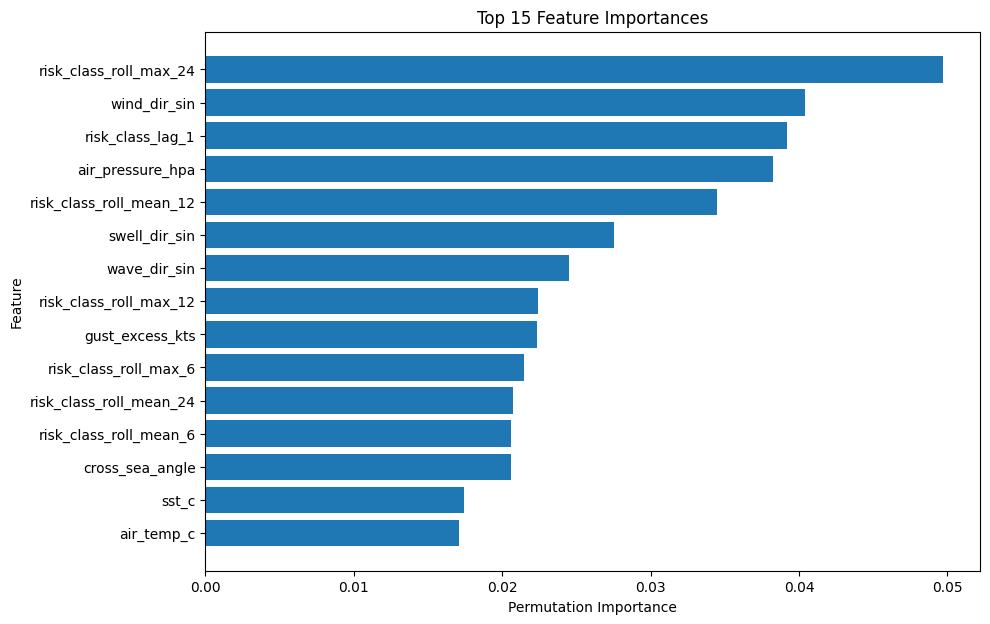

In [59]:
top_features = (importance_df.head(15).sort_values("Importance Mean"))
plt.figure(figsize=(10, 7))
plt.barh(top_features["Feature"],top_features["Importance Mean"])
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances")
plt.show()

### Part T - SPATIAL DISTRIBUTION SHIFT

#### Compare Training vs Digha

In [60]:
distribution_features = [
    "wave_height_m",
    "wave_period_s",
    "swell_height_m",
    "swell_period_s",
    "wind_speed_kts",
    "wind_gust_kts",
    "air_pressure_hpa"
]

distribution_summary = []

for feature in distribution_features:

    distribution_summary.append({

        "Feature": feature,

        "Training Mean":
            X_dev[feature].mean(),

        "Digha Mean":
            X_digha[feature].mean(),

        "Training Std":
            X_dev[feature].std(),

        "Digha Std":
            X_digha[feature].std(),

        "Training Min":
            X_dev[feature].min(),

        "Digha Min":
            X_digha[feature].min(),

        "Training Max":
            X_dev[feature].max(),

        "Digha Max":
            X_digha[feature].max()
    })

distribution_df = pd.DataFrame(
    distribution_summary
)

display(distribution_df)

,Feature,Training Mean,Digha Mean,Training Std,Digha Std,Training Min,Digha Min,Training Max,Digha Max
0,wave_height_m,1.065651,1.184308,0.819765,0.963576,0.000000,0.000000,27.129307,9.292585
1,wave_period_s,6.903684,7.917492,3.148541,3.209536,0.000000,0.000000,26.221220,16.299999
2,swell_height_m,0.765218,0.845134,0.606126,0.661291,0.000000,0.000000,17.634048,6.040180
3,swell_period_s,7.051068,7.789026,2.923381,2.948539,0.000000,0.000000,32.776527,19.182793
4,wind_speed_kts,10.272855,9.961835,5.213101,5.816297,0.000000,0.000000,69.199997,56.200001
5,wind_gust_kts,15.218813,15.485570,6.661875,7.431725,0.800000,0.400000,110.800003,84.400002
6,air_pressure_hpa,1008.718018,1008.790161,5.941616,5.281537,933.799988,974.700012,1022.000000,1022.500000


### Part U - HIERARCHICAL CLASSIFICATION

#### Create Binary Dangerous Target

In [61]:
y_dev_dangerous = (
    y_dev >= 2
).astype(int)

y_val_dangerous = (
    y_val >= 2
).astype(int)

print(
    y_dev_dangerous.value_counts()
)

target_risk_class
0    658583
1      7177
Name: count, dtype: int64


#### Train Dangerous Detector

In [62]:
danger_model = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=0.05,
    max_iter=400,
    max_depth=8,
    min_samples_leaf=20,
    l2_regularization=1.0,
    max_bins=255,
    random_state=42
)

danger_model.fit(
    X_dev,
    y_dev_dangerous,
    sample_weight=np.where(
        y_dev_dangerous == 1,
        3.0,
        1.0
    )
)

HistGradientBoostingClassifier(l2_regularization=1.0, learning_rate=0.05,
                               max_depth=8, max_iter=400, random_state=42)

#### Evaluate Dangerous Detector

In [63]:
danger_pred = danger_model.predict(X_val)

print(classification_report(y_val_dangerous,danger_pred,target_names=["SAFE","DANGEROUS"],zero_division=0))

danger_metrics = dangerous_metrics(y_val,np.where(danger_pred == 1,2,0),"Hierarchical Dangerous Detector")

              precision    recall  f1-score   support

        SAFE       0.99      1.00      0.99    164559
   DANGEROUS       0.65      0.63      0.64      2337

    accuracy                           0.99    166896
   macro avg       0.82      0.81      0.82    166896
weighted avg       0.99      0.99      0.99    166896

Hierarchical Dangerous Detector
Dangerous Precision: 0.6456
Dangerous Recall:    0.6307
Dangerous F1:        0.6381
False Positive Rate: 0.0049
False Negative Rate: 0.3693


### Part V - EVENT LEVEL EVALUATION

#### Create Dangerous Event IDs

In [64]:
# ============================================================
# PART V - LOCATION-AWARE EVENT CREATION
# ============================================================

def create_events(
    timestamps,
    dangerous_mask
):

    temp = pd.DataFrame({
        "datetime": pd.to_datetime(
            timestamps
        ),
        "dangerous": np.asarray(
            dangerous_mask
        )
    }).sort_values(
        "datetime"
    ).reset_index(drop=True)


    events = []

    start_time = None
    previous_time = None


    for _, row in temp.iterrows():

        current_time = row["datetime"]

        if row["dangerous"]:

            if (
                start_time is None
                or
                previous_time is None
                or
                current_time - previous_time
                > pd.Timedelta(hours=1)
            ):

                if start_time is not None:
                    events.append({
                        "start": start_time,
                        "end": previous_time
                    })

                start_time = current_time

        else:

            if start_time is not None:

                events.append({
                    "start": start_time,
                    "end": previous_time
                })

                start_time = None


        previous_time = current_time


    if start_time is not None:

        events.append({
            "start": start_time,
            "end": previous_time
        })


    return events

#### Event Level Detection

In [65]:
# ============================================================
# LOCATION-AWARE EVENT METRICS
# ============================================================

def event_level_metrics_by_location(
    df_eval,
    actual_dangerous,
    predicted_dangerous
):

    temp = df_eval[
        [
            "location_id",
            "datetime"
        ]
    ].copy()
    temp["actual"] = np.asarray(
        actual_dangerous
    ).astype(bool)

    temp["predicted"] = np.asarray(
        predicted_dangerous
    ).astype(bool)

    results = []

    for location, group in temp.groupby("location_id"):
        group = group.sort_values("datetime").reset_index(drop=True)
        actual_events = create_events(group["datetime"],group["actual"])

        predicted_events = create_events(group["datetime"],group["predicted"])

        detected = 0

        for actual_event in actual_events:
            for predicted_event in predicted_events:
                overlap = (
                    predicted_event["start"]
                    <= actual_event["end"]
                    and
                    predicted_event["end"]
                    >= actual_event["start"]
                )
                if overlap:
                    detected += 1
                    break


        event_recall = (
            detected / len(actual_events)
            if len(actual_events) > 0
            else np.nan
        )

        results.append({
            "location_id": location,
            "actual_events":
                len(actual_events),
            "predicted_events":
                len(predicted_events),
            "detected_events":
                detected,
            "event_recall":
                event_recall
        })


    return pd.DataFrame(
        results
    )

#### Run Event Evaluation

In [66]:
# ============================================================
# 2025 EVENT EVALUATION
# ============================================================

y_2025_dangerous = (
    y_2025 >= 2
).astype(int)


pred_2025_dangerous = (
    final_dev_model.predict(X_2025) >= 2
).astype(int)


event_results_2025 = (
    event_level_metrics_by_location(
        temporal_test,
        y_2025_dangerous,
        pred_2025_dangerous
    )
)


display(
    event_results_2025
)


print(
    "Overall event recall:",
    event_results_2025[
        "detected_events"
    ].sum()
    /
    max(
        event_results_2025[
            "actual_events"
        ].sum(),
        1
    )
)

,location_id,actual_events,predicted_events,detected_events,event_recall
0,chennai_tn,0,7,0,NaN
1,cyclone_amphan_deep,37,53,28,0.756757
2,cyclone_amphan_north,7,35,4,0.571429
3,cyclone_asani_track,32,45,27,0.843750
4,cyclone_biparjoy_gujarat,21,56,20,0.952381
5,cyclone_dana_track,7,35,4,0.571429
6,cyclone_mandous_track,16,43,11,0.687500
7,cyclone_michaung_track,5,17,5,1.000000
8,cyclone_mocha_core,24,67,19,0.791667
9,cyclone_remal_track,7,33,3,0.428571


Overall event recall: 0.6965811965811965


## Part W - FINAL MODEL SELECTION

### Part X - RETRAIN FINAL MODEL

#### Train FInal Candidate on 2020 - 2024
<p>Once the 2024 validation experiments identify the best configuration, we retrain using all approved 2020–2024 non-Digha data.
<br>
For now, this uses the baseline configuration; later replace it with whichever configuration wins validation.</p>

## Part N8 - EXTREME SEVERITY RECOVERY (FINAL FINE-TUNING)

This stage is specifically designed for the remaining **HIGH vs EXTREME** confusion.

Rules:
- 2024 validation is the **only** dataset used for N8 model/threshold selection.
- 2025 temporal and Digha spatial data are not used for tuning.
- The existing multiclass HGBDT remains the base classifier.
- N8 can only change an existing **HIGH** prediction to **EXTREME**.
- LOW/MODERATE predictions are never promoted.
- Existing EXTREME predictions remain EXTREME.
- Therefore the dangerous/non-dangerous boundary is unchanged by N8.
- The existing operational dangerous threshold `P(HIGH)+P(EXTREME)` is unchanged.
- N8 uses a dedicated HIGH-vs-EXTREME specialist and blends its score with the base model's relative EXTREME probability.


In [68]:
# ============================================================
# PART N8 - EXTREME SEVERITY RECOVERY
# ============================================================
# FINAL severity refinement aimed at the HIGH -> EXTREME boundary.
#
# IMPORTANT:
#   * 2024 validation ONLY is used for model/threshold selection.
#   * 2025 and Digha remain untouched until final evaluation.
#   * Only HIGH -> EXTREME promotions are allowed.
#   * LOW/MODERATE are never promoted.
#   * Existing EXTREME predictions remain EXTREME.
#   * Dangerous membership is therefore unchanged.
#   * DANGEROUS_THRESHOLD is not modified.

N8_MIN_DANGEROUS_RECALL = 0.90
N8_MIN_HIGH_RECALL = 0.70
N8_MIN_MACRO_F1 = 0.55

# ------------------------------------------------------------
# Candidate base models
# ------------------------------------------------------------
n8_base_pool = (
    tuning_results_df
    .sort_values(
        ["macro_f1", "dangerous_recall", "balanced_accuracy"],
        ascending=False
    )
    .drop_duplicates("name")
    .head(8)["name"]
    .tolist()
)

n8_base_pool = [
    name for name in n8_base_pool
    if name in tuning_models
]

if not n8_base_pool:
    raise RuntimeError("N8: no base HGBDT candidates available.")

print("N8 base candidates:")
print(n8_base_pool)

# ------------------------------------------------------------
# Dedicated HIGH-vs-EXTREME training set
# ------------------------------------------------------------
n8_danger_mask = y_dev >= 2

X_n8_danger = X_dev.loc[n8_danger_mask].copy()
y_n8_danger = y_dev.loc[n8_danger_mask].copy()

# HIGH = 0, EXTREME = 1
y_n8_severity = (
    y_n8_danger == 3
).astype("int8")

print("N8 dangerous training rows:", len(X_n8_danger))
print("N8 HIGH rows:", int((y_n8_severity == 0).sum()))
print("N8 EXTREME rows:", int((y_n8_severity == 1).sum()))

# ------------------------------------------------------------
# More aggressive specialist family.
# The binary specialist sees only the dangerous boundary,
# so its capacity is spent distinguishing HIGH from EXTREME.
# ------------------------------------------------------------
n8_specialist_configs = [
    {
        "name": "n8_d6_leaf5_x6",
        "learning_rate": 0.03,
        "max_iter": 600,
        "max_depth": 6,
        "min_samples_leaf": 5,
        "l2_regularization": 1.0,
        "extreme_multiplier": 6.0
    },
    {
        "name": "n8_d8_leaf5_x8",
        "learning_rate": 0.03,
        "max_iter": 600,
        "max_depth": 8,
        "min_samples_leaf": 5,
        "l2_regularization": 1.0,
        "extreme_multiplier": 8.0
    },
    {
        "name": "n8_d8_leaf10_x10",
        "learning_rate": 0.02,
        "max_iter": 800,
        "max_depth": 8,
        "min_samples_leaf": 10,
        "l2_regularization": 1.0,
        "extreme_multiplier": 10.0
    },
    {
        "name": "n8_d10_leaf5_x10",
        "learning_rate": 0.02,
        "max_iter": 800,
        "max_depth": 10,
        "min_samples_leaf": 5,
        "l2_regularization": 1.0,
        "extreme_multiplier": 10.0
    },
    {
        "name": "n8_d10_leaf10_x15",
        "learning_rate": 0.02,
        "max_iter": 800,
        "max_depth": 10,
        "min_samples_leaf": 10,
        "l2_regularization": 3.0,
        "extreme_multiplier": 15.0
    },
    {
        "name": "n8_d12_leaf5_x15",
        "learning_rate": 0.02,
        "max_iter": 800,
        "max_depth": 12,
        "min_samples_leaf": 5,
        "l2_regularization": 3.0,
        "extreme_multiplier": 15.0
    },
    {
        "name": "n8_d8_leaf5_x20",
        "learning_rate": 0.015,
        "max_iter": 900,
        "max_depth": 8,
        "min_samples_leaf": 5,
        "l2_regularization": 3.0,
        "extreme_multiplier": 20.0
    },
    {
        "name": "n8_d10_leaf5_x20",
        "learning_rate": 0.015,
        "max_iter": 900,
        "max_depth": 10,
        "min_samples_leaf": 5,
        "l2_regularization": 3.0,
        "extreme_multiplier": 20.0
    }
]

n8_specialist_models = {}
n8_results = []

# ------------------------------------------------------------
# Validation evaluator
# ------------------------------------------------------------
def _n8_add_result(
    pred,
    base_name,
    specialist_name,
    threshold,
    alpha,
    method
):
    danger_true = (y_val >= 2).astype(int)
    danger_pred = (pred >= 2).astype(int)

    n8_results.append({
        "method": method,
        "base_model": base_name,
        "specialist": specialist_name,
        "threshold": float(threshold),
        "alpha": float(alpha),

        "accuracy": accuracy_score(
            y_val, pred
        ),
        "macro_f1": f1_score(
            y_val, pred,
            average="macro",
            zero_division=0
        ),
        "macro_precision": precision_score(
            y_val, pred,
            average="macro",
            zero_division=0
        ),
        "macro_recall": recall_score(
            y_val, pred,
            average="macro",
            zero_division=0
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_val, pred
        ),
        "high_recall": recall_score(
            y_val, pred,
            labels=[2],
            average="macro",
            zero_division=0
        ),
        "extreme_recall": recall_score(
            y_val, pred,
            labels=[3],
            average="macro",
            zero_division=0
        ),
        "dangerous_recall": recall_score(
            danger_true,
            danger_pred,
            zero_division=0
        ),
        "dangerous_precision": precision_score(
            danger_true,
            danger_pred,
            zero_division=0
        ),
        "false_alarm_rate": (
            (
                (danger_pred == 1)
                &
                (danger_true == 0)
            ).sum()
            /
            max(
                (danger_true == 0).sum(),
                1
            )
        )
    })


for cfg in n8_specialist_configs:

    print("\nTraining N8 specialist:", cfg["name"])

    specialist_weights = np.where(
        y_n8_severity.to_numpy() == 1,
        cfg["extreme_multiplier"],
        1.0
    ).astype("float32")

    specialist = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=cfg["learning_rate"],
        max_iter=cfg["max_iter"],
        max_depth=cfg["max_depth"],
        min_samples_leaf=cfg["min_samples_leaf"],
        l2_regularization=cfg["l2_regularization"],
        max_bins=255,
        early_stopping=False,
        random_state=42
    )

    specialist.fit(
        X_n8_danger,
        y_n8_severity,
        sample_weight=specialist_weights
    )

    n8_specialist_models[cfg["name"]] = specialist

    specialist_p = (
        specialist.predict_proba(X_val)[:, 1]
    )

    for base_name in n8_base_pool:

        base_model = tuning_models[base_name]

        base_pred = base_model.predict(X_val)
        base_proba = base_model.predict_proba(X_val)

        # Relative EXTREME probability inside the dangerous pair.
        # This focuses on HIGH vs EXTREME rather than overall
        # four-class probability magnitude.
        pair_denominator = (
            base_proba[:, 2]
            + base_proba[:, 3]
            + 1e-9
        )

        base_relative_extreme = (
            base_proba[:, 3]
            / pair_denominator
        )

        # Only base-HIGH observations can be promoted.
        high_gate = (
            base_pred == 2
        )

        # Blend the dedicated specialist with the base model's
        # HIGH-vs-EXTREME relative probability.
        for alpha in np.arange(0.0, 1.01, 0.25):

            severity_score = (
                alpha * specialist_p
                +
                (1.0 - alpha)
                * base_relative_extreme
            )

            for threshold in np.arange(0.10, 0.901, 0.01):

                pred = base_pred.copy()

                promote = (
                    high_gate
                    &
                    (severity_score >= threshold)
                )

                pred[promote] = 3

                _n8_add_result(
                    pred=pred,
                    base_name=base_name,
                    specialist_name=cfg["name"],
                    threshold=threshold,
                    alpha=alpha,
                    method="specialist_blend"
                )

# ------------------------------------------------------------
# Also test the pure specialist and pure base-relative scores.
# ------------------------------------------------------------
for base_name in n8_base_pool:

    base_model = tuning_models[base_name]
    base_pred = base_model.predict(X_val)
    base_proba = base_model.predict_proba(X_val)

    pair_denominator = (
        base_proba[:, 2]
        + base_proba[:, 3]
        + 1e-9
    )

    base_relative_extreme = (
        base_proba[:, 3]
        / pair_denominator
    )

    high_gate = (
        base_pred == 2
    )

    for threshold in np.arange(0.05, 0.901, 0.01):

        pred = base_pred.copy()

        pred[
            high_gate
            &
            (base_relative_extreme >= threshold)
        ] = 3

        _n8_add_result(
            pred=pred,
            base_name=base_name,
            specialist_name="none",
            threshold=threshold,
            alpha=0.0,
            method="base_relative_extreme"
        )

n8_results_df = pd.DataFrame(n8_results)

# ------------------------------------------------------------
# Candidate selection.
#
# The priority is EXTREME recall, but we retain guardrails so
# the model does not solve EXTREME recall by destroying HIGH.
# ------------------------------------------------------------
n8_eligible = n8_results_df[
    (n8_results_df["dangerous_recall"] >= N8_MIN_DANGEROUS_RECALL)
    &
    (n8_results_df["high_recall"] >= N8_MIN_HIGH_RECALL)
    &
    (n8_results_df["macro_f1"] >= N8_MIN_MACRO_F1)
].copy()

if len(n8_eligible) == 0:
    print(
        "N8 strict guardrails produced no candidate. "
        "Relaxing HIGH Recall to 0.60 while keeping "
        "Dangerous Recall >= 0.90 and Macro F1 >= 0.50."
    )

    n8_eligible = n8_results_df[
        (n8_results_df["dangerous_recall"] >= 0.90)
        &
        (n8_results_df["high_recall"] >= 0.60)
        &
        (n8_results_df["macro_f1"] >= 0.50)
    ].copy()

if len(n8_eligible) == 0:
    n8_eligible = n8_results_df[
        n8_results_df["dangerous_recall"] >= 0.90
    ].copy()

if len(n8_eligible) == 0:
    raise RuntimeError("N8 could not produce a candidate.")

# Select by:
# 1) EXTREME recall
# 2) Macro F1
# 3) HIGH recall
# 4) Balanced accuracy
# 5) Dangerous precision
n8_best = (
    n8_eligible
    .sort_values(
        [
            "extreme_recall",
            "macro_f1",
            "high_recall",
            "balanced_accuracy",
            "dangerous_precision"
        ],
        ascending=False
    )
    .iloc[0]
)

N8_METHOD = str(n8_best["method"])
N8_BASE_MODEL = str(n8_best["base_model"])
N8_SPECIALIST_NAME = str(n8_best["specialist"])
N8_THRESHOLD = float(n8_best["threshold"])
N8_ALPHA = float(n8_best["alpha"])

best_model_name = N8_BASE_MODEL
best_development_model = tuning_models[best_model_name]

# Re-select the operational dangerous threshold for the N8-selected
# base model using the SAME existing rule and 2024 validation only.
# The strategy is unchanged: Dangerous = HIGH + EXTREME and the
# selected threshold must provide >= 90% dangerous recall when possible.
n8_val_base_proba = best_development_model.predict_proba(X_val)
n8_p_dangerous_val = (
    n8_val_base_proba[:, 2]
    + n8_val_base_proba[:, 3]
)
n8_y_dangerous_val = (y_val >= 2).astype(int)

n8_threshold_rows = []

for threshold in np.arange(0.01, 0.51, 0.01):
    n8_pred_danger = (
        n8_p_dangerous_val >= threshold
    ).astype(int)

    n8_dr = recall_score(
        n8_y_dangerous_val,
        n8_pred_danger,
        zero_division=0
    )

    n8_dp = precision_score(
        n8_y_dangerous_val,
        n8_pred_danger,
        zero_division=0
    )

    n8_far = (
        (
            (n8_pred_danger == 1)
            &
            (n8_y_dangerous_val == 0)
        ).sum()
        /
        max(
            (n8_y_dangerous_val == 0).sum(),
            1
        )
    )

    n8_threshold_rows.append({
        "threshold": float(threshold),
        "dangerous_recall": n8_dr,
        "dangerous_precision": n8_dp,
        "false_alarm_rate": n8_far
    })

n8_threshold_df = pd.DataFrame(n8_threshold_rows)

n8_threshold_eligible = n8_threshold_df[
    n8_threshold_df["dangerous_recall"] >= 0.90
].copy()

if len(n8_threshold_eligible) > 0:
    n8_threshold_row = (
        n8_threshold_eligible
        .sort_values(
            [
                "dangerous_precision",
                "false_alarm_rate",
                "dangerous_recall"
            ],
            ascending=[False, True, False]
        )
        .iloc[0]
    )
else:
    n8_threshold_row = (
        n8_threshold_df
        .sort_values(
            [
                "dangerous_recall",
                "dangerous_precision",
                "false_alarm_rate"
            ],
            ascending=[False, False, True]
        )
        .iloc[0]
    )

DANGEROUS_THRESHOLD = float(
    n8_threshold_row["threshold"]
)

print(
    "N8-updated dangerous threshold:",
    f"{DANGEROUS_THRESHOLD:.2f}"
)
print(
    "N8 validation dangerous recall:",
    f"{n8_threshold_row['dangerous_recall']:.4f}"
)
print(
    "N8 validation dangerous precision:",
    f"{n8_threshold_row['dangerous_precision']:.4f}"
)
print(
    "N8 validation false alarm rate:",
    f"{n8_threshold_row['false_alarm_rate']:.4f}"
)

print("\n" + "=" * 78)
print("N8 SELECTED EXTREME RECOVERY STRATEGY")
print("=" * 78)
print(n8_best.to_frame("value"))

print("\nBase model:", N8_BASE_MODEL)
print("Method:", N8_METHOD)
print("Specialist:", N8_SPECIALIST_NAME)
print("Blend alpha:", N8_ALPHA)
print("Severity threshold:", N8_THRESHOLD)

# ------------------------------------------------------------
# Explicit safety proof.
# N8 may only convert HIGH -> EXTREME.
# Therefore dangerous membership must be identical.
# ------------------------------------------------------------
n8_base_pred = best_development_model.predict(X_val)

if N8_METHOD == "base_relative_extreme":

    n8_base_proba = (
        best_development_model
        .predict_proba(X_val)
    )

    n8_pair = (
        n8_base_proba[:, 2]
        + n8_base_proba[:, 3]
        + 1e-9
    )

    n8_score = (
        n8_base_proba[:, 3]
        / n8_pair
    )

else:

    n8_base_proba = (
        best_development_model
        .predict_proba(X_val)
    )

    n8_pair = (
        n8_base_proba[:, 2]
        + n8_base_proba[:, 3]
        + 1e-9
    )

    n8_base_relative = (
        n8_base_proba[:, 3]
        / n8_pair
    )

    n8_specialist = (
        n8_specialist_models[N8_SPECIALIST_NAME]
    )

    n8_specialist_score = (
        n8_specialist
        .predict_proba(X_val)[:, 1]
    )

    n8_score = (
        N8_ALPHA * n8_specialist_score
        +
        (1.0 - N8_ALPHA) * n8_base_relative
    )

n8_selected_pred = n8_base_pred.copy()

n8_selected_pred[
    (n8_base_pred == 2)
    &
    (n8_score >= N8_THRESHOLD)
] = 3

assert np.array_equal(
    (n8_base_pred >= 2),
    (n8_selected_pred >= 2)
)

print("\n✓ N8 dangerous membership is unchanged.")

print(
    "Validation EXTREME recall:",
    recall_score(
        y_val,
        n8_selected_pred,
        labels=[3],
        average="macro",
        zero_division=0
    )
)

print(
    "Validation HIGH recall:",
    recall_score(
        y_val,
        n8_selected_pred,
        labels=[2],
        average="macro",
        zero_division=0
    )
)

print(
    "Validation Macro F1:",
    f1_score(
        y_val,
        n8_selected_pred,
        average="macro",
        zero_division=0
    )
)

print(
    "Validation Dangerous Recall:",
    recall_score(
        (y_val >= 2).astype(int),
        (n8_selected_pred >= 2).astype(int),
        zero_division=0
    )
)

# Compact leaderboard for inspection.
display(
    n8_eligible[
        [
            "method",
            "base_model",
            "specialist",
            "threshold",
            "alpha",
            "extreme_recall",
            "high_recall",
            "macro_f1",
            "balanced_accuracy",
            "dangerous_recall",
            "dangerous_precision"
        ]
    ]
    .sort_values(
        [
            "extreme_recall",
            "macro_f1",
            "high_recall"
        ],
        ascending=False
    )
    .head(20)
    .reset_index(drop=True)
)

def n8_apply_severity(base_model, severity_model, X):
    """
    Apply the selected N8 HIGH -> EXTREME rule.

    Only an existing HIGH prediction may be promoted.
    LOW/MODERATE stay unchanged.
    Existing EXTREME stays EXTREME.
    """
    base_pred = base_model.predict(X)
    base_proba = base_model.predict_proba(X)

    pair = (
        base_proba[:, 2]
        + base_proba[:, 3]
        + 1e-9
    )

    base_relative = (
        base_proba[:, 3]
        / pair
    )

    if N8_METHOD == "base_relative_extreme":
        score = base_relative

    elif N8_METHOD == "specialist_blend":
        if severity_model is None:
            raise RuntimeError(
                "N8 specialist model is required for specialist_blend."
            )

        specialist_p = (
            severity_model.predict_proba(X)[:, 1]
        )

        score = (
            N8_ALPHA * specialist_p
            +
            (1.0 - N8_ALPHA) * base_relative
        )

    else:
        raise RuntimeError(
            f"Unknown N8 method: {N8_METHOD}"
        )

    refined_pred = base_pred.copy()

    refined_pred[
        (base_pred == 2)
        &
        (score >= N8_THRESHOLD)
    ] = 3

    # Critical safety invariant.
    assert np.array_equal(
        (base_pred >= 2),
        (refined_pred >= 2)
    )

    return refined_pred


N8 base candidates:
['refine_l2_3', 'refine_lr_002', 'risk_history_l2_3', 'refine_leaf_30', 'risk_history_lr_002', 'refine_leaf_10', 'risk_history_leaf_30', 'refine_depth_12']
N8 dangerous training rows: 7177
N8 HIGH rows: 6561
N8 EXTREME rows: 616

Training N8 specialist: n8_d6_leaf5_x6

Training N8 specialist: n8_d8_leaf5_x8

Training N8 specialist: n8_d8_leaf10_x10

Training N8 specialist: n8_d10_leaf5_x10

Training N8 specialist: n8_d10_leaf10_x15

Training N8 specialist: n8_d12_leaf5_x15

Training N8 specialist: n8_d8_leaf5_x20

Training N8 specialist: n8_d10_leaf5_x20
N8-updated dangerous threshold: 0.50
N8 validation dangerous recall: 0.9277
N8 validation dangerous precision: 0.3079
N8 validation false alarm rate: 0.0296

N8 SELECTED EXTREME RECOVERY STRATEGY
                                     value
method               base_relative_extreme
base_model                  refine_leaf_10
specialist                            none
threshold                             0.05
alpha   

,method,base_model,specialist,threshold,alpha,extreme_recall,high_recall,macro_f1,balanced_accuracy,dangerous_recall,dangerous_precision
0,base_relative_extreme,refine_leaf_10,none,0.05,0.0,0.784615,0.834067,0.626740,0.866580,0.925973,0.308043
1,base_relative_extreme,risk_history_lr_002,none,0.05,0.0,0.769231,0.845951,0.633897,0.865789,0.926401,0.308492
2,base_relative_extreme,refine_leaf_10,none,0.06,0.0,0.738462,0.842430,0.629808,0.857132,0.925973,0.308043
3,base_relative_extreme,refine_l2_3,none,0.05,0.0,0.723077,0.839349,0.640794,0.853645,0.911425,0.319724
4,base_relative_extreme,refine_l2_3,none,0.06,0.0,0.707692,0.845070,0.645488,0.851229,0.911425,0.319724
5,base_relative_extreme,refine_depth_12,none,0.05,0.0,0.707692,0.843750,0.642174,0.851145,0.913564,0.324715
6,base_relative_extreme,risk_history_lr_002,none,0.06,0.0,0.707692,0.855194,0.637644,0.852715,0.926401,0.308492
7,base_relative_extreme,risk_history_leaf_30,none,0.05,0.0,0.707692,0.842430,0.636915,0.849992,0.920411,0.313100
8,base_relative_extreme,refine_leaf_10,none,0.07,0.0,0.707692,0.851673,0.634679,0.851750,0.925973,0.308043
9,base_relative_extreme,risk_history_l2_3,none,0.05,0.0,0.692308,0.840669,0.638765,0.845966,0.917843,0.316465


In [ ]:
# ============================================================
# FINAL TRAINING DATA
# 2020-2024 NON-SPATIAL HOLDOUT LOCATIONS
# ============================================================

X_final_train = (
    df[
        train_mask
    ][FEATURE_COLUMNS]
    .astype("float32")
)


y_final_train = (
    df[
        train_mask
    ]["target_risk_class"]
    .astype("int8")
)


final_counts = (
    y_final_train
    .value_counts()
    .sort_index()
)


final_class_weights = {
    int(cls):
    len(y_final_train)
    /
    (
        4 * count
    )
    for cls, count
    in final_counts.items()
}


final_safety_weights = (
    final_class_weights.copy()
)


if 2 in final_safety_weights:
    final_safety_weights[2] *= 2.0


if 3 in final_safety_weights:
    final_safety_weights[3] *= 3.0


final_sample_weight = (
    y_final_train
    .map(final_safety_weights)
    .to_numpy(
        dtype="float32"
    )
)


print(
    "Final training rows:",
    len(X_final_train)
)

print(
    "Final feature count:",
    X_final_train.shape[1]
)

print(
    "Final safety weights:",
    final_safety_weights
)

Final training rows: 832656
Final feature count: 41
Final safety weights: {0: 0.3715131158600356, 1: 0.7920160713470407, 2: 47.1332503113325, 3: 917.022026431718}


#### Final HGBDT

In [ ]:
# ============================================================
# FINAL MODEL RETRAINING
# ============================================================
# Retrain the selected BASE HGBDT on the complete approved
# 2020-2024 non-Digha training data.
#
# N8 severity selection was performed ONLY on 2024 validation.
# The final HIGH-vs-EXTREME specialist is trained separately.

selected_params = next(
    params
    for params in experiments
    if params["name"] == best_model_name
)

print("Selected base configuration:")
print(selected_params)

final_model = HistGradientBoostingClassifier(
    loss="log_loss",
    learning_rate=selected_params["learning_rate"],
    max_iter=selected_params["max_iter"],
    max_depth=selected_params["max_depth"],
    min_samples_leaf=selected_params["min_samples_leaf"],
    l2_regularization=selected_params["l2_regularization"],
    max_bins=255,
    early_stopping=False,
    random_state=42
)

start = time.perf_counter()

final_model.fit(
    X_final_train,
    y_final_train,
    sample_weight=final_sample_weight
)

final_training_time = time.perf_counter() - start

print(
    f"Final base training time: "
    f"{final_training_time:.2f} seconds"
)

print("✓ Final base model trained.")


Selected base configuration:
{'name': 'refine_leaf_10', 'learning_rate': 0.03, 'max_iter': 400, 'max_depth': 10, 'min_samples_leaf': 10, 'l2_regularization': 1}
Final base training time: 211.65 seconds
✓ Final base model trained.


### Part X2 - Retrain Selected HIGH-vs-EXTREME Severity Model

The selected severity rule is retrained on all approved 2020–2024 non-Digha data.

The 2025 and Digha sets remain untouched.


In [ ]:
# ============================================================
# PART X2 - FINAL N8 HIGH / EXTREME SPECIALIST
# ============================================================

final_severity_specialist = None

if N8_METHOD == "specialist_blend":

    selected_cfg = next(
        cfg
        for cfg in n8_specialist_configs
        if cfg["name"] == N8_SPECIALIST_NAME
    )

    final_danger_mask = y_final_train >= 2

    X_final_danger = (
        X_final_train.loc[
            final_danger_mask
        ].copy()
    )

    y_final_danger = (
        y_final_train.loc[
            final_danger_mask
        ].copy()
    )

    y_final_severity = (
        y_final_danger == 3
    ).astype("int8")

    final_severity_weights = np.where(
        y_final_severity.to_numpy() == 1,
        selected_cfg["extreme_multiplier"],
        1.0
    ).astype("float32")

    final_severity_specialist = HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=selected_cfg["learning_rate"],
        max_iter=selected_cfg["max_iter"],
        max_depth=selected_cfg["max_depth"],
        min_samples_leaf=selected_cfg["min_samples_leaf"],
        l2_regularization=selected_cfg["l2_regularization"],
        max_bins=255,
        early_stopping=False,
        random_state=42
    )

    start = time.perf_counter()

    final_severity_specialist.fit(
        X_final_danger,
        y_final_severity,
        sample_weight=final_severity_weights
    )

    severity_training_time = (
        time.perf_counter() - start
    )

    print(
        "✓ Final HIGH-vs-EXTREME specialist trained:",
        N8_SPECIALIST_NAME
    )
    print(
        f"Specialist training time: "
        f"{severity_training_time:.2f} seconds"
    )

else:
    print(
        "N8 selected the base-relative EXTREME score; "
        "no separate specialist is required."
    )

print("N8 method:", N8_METHOD)
print("N8 alpha:", N8_ALPHA)
print("N8 threshold:", N8_THRESHOLD)


N8 selected the base-relative EXTREME score; no separate specialist is required.
N8 method: base_relative_extreme
N8 alpha: 0.0
N8 threshold: 0.05


## Part Y - FINAL 2025 EVALUATION
##### Now and only now, we will touch the 2025 test

### 2025 Final Scorecard

In [77]:
# ============================================================
# PART Y - FINAL 2025 EVALUATION
# ============================================================
# 2025 is evaluated ONLY now.
# N8 was selected using 2024 validation only.

base_pred_2025 = final_model.predict(X_2025)
proba_2025 = final_model.predict_proba(X_2025)

severity_pred_2025 = n8_apply_severity(
    final_model,
    final_severity_specialist,
    X_2025
)

final_2025 = evaluate_model(
    _N7PredictionAdapter(severity_pred_2025),
    X_2025,
    y_2025,
    "FINAL TEMPORAL GENERALIZATION — 2025 (N8 EXTREME RECOVERY)"
)

final_2025_danger = dangerous_metrics(
    y_2025,
    severity_pred_2025,
    "FINAL 2025 DANGEROUS EVENTS — N8"
)

# ------------------------------------------------------------
# Operational dangerous threshold — UNCHANGED
# ------------------------------------------------------------
p_dangerous_2025 = (
    proba_2025[:, 2]
    +
    proba_2025[:, 3]
)

actual_dangerous_2025 = (
    y_2025 >= 2
).astype(int)

threshold_pred_2025 = (
    p_dangerous_2025
    >= DANGEROUS_THRESHOLD
).astype(int)

threshold_recall_2025 = recall_score(
    actual_dangerous_2025,
    threshold_pred_2025,
    zero_division=0
)

threshold_precision_2025 = precision_score(
    actual_dangerous_2025,
    threshold_pred_2025,
    zero_division=0
)

threshold_false_alarm_2025 = (
    (
        (threshold_pred_2025 == 1)
        &
        (actual_dangerous_2025 == 0)
    ).sum()
    /
    max(
        (actual_dangerous_2025 == 0).sum(),
        1
    )
)

print("\n2025 OPERATIONAL SAFETY METRICS")
print("--------------------------------")
print(
    f"Dangerous Recall:    "
    f"{threshold_recall_2025:.4f}"
)
print(
    f"Dangerous Precision: "
    f"{threshold_precision_2025:.4f}"
)
print(
    f"False Alarm Rate:    "
    f"{threshold_false_alarm_2025:.4f}"
)
print(
    f"Dangerous Threshold: "
    f"{DANGEROUS_THRESHOLD:.2f}"
)

print("\nN8 SEVERITY METRICS")
print("-------------------")
print(
    f"HIGH Recall:    "
    f"{recall_score(y_2025, severity_pred_2025, labels=[2], average='macro', zero_division=0):.4f}"
)
print(
    f"EXTREME Recall: "
    f"{recall_score(y_2025, severity_pred_2025, labels=[3], average='macro', zero_division=0):.4f}"
)



FINAL TEMPORAL GENERALIZATION — 2025 (N8 EXTREME RECOVERY)
Accuracy:          0.9354
Macro F1:          0.6232
Macro Precision:   0.5838
Macro Recall:      0.7270
Balanced Accuracy: 0.7270

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.96     94423
    MODERATE       0.94      0.91      0.92     69809
        HIGH       0.34      0.88      0.49      1968
     EXTREME       0.09      0.17      0.12        12

    accuracy                           0.94    166212
   macro avg       0.58      0.73      0.62    166212
weighted avg       0.95      0.94      0.94    166212

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,90292,4130,1,0
Actual MODERATE,3013,63463,3321,12
Actual HIGH,0,236,1724,8
Actual EXTREME,0,2,8,2


FINAL 2025 DANGEROUS EVENTS — N8
Dangerous Precision: 0.3432
Dangerous Recall:    0.8798
Dangerous F1:        0.4938
False Positive Rate: 0.0203
False Negative Rate: 0.1202

2025 OPERATIONAL SAFETY METRICS
--------------------------------
Dangerous Recall:    0.8808
Dangerous Precision: 0.3432
False Alarm Rate:    0.0203
Dangerous Threshold: 0.50

N8 SEVERITY METRICS
-------------------
HIGH Recall:    0.8760
EXTREME Recall: 0.1667


## Part Z - FINAL DIGHA EVALUATION

### Digha Final Scorecard

In [78]:
# ============================================================
# PART Z - FINAL DIGHA EVALUATION
# ============================================================
# Digha is evaluated only after the N8 rule is frozen.

base_pred_digha = final_model.predict(X_digha)
proba_digha = final_model.predict_proba(X_digha)

severity_pred_digha = n8_apply_severity(
    final_model,
    final_severity_specialist,
    X_digha
)

final_digha = evaluate_model(
    _N7PredictionAdapter(severity_pred_digha),
    X_digha,
    y_digha,
    "FINAL SPATIAL GENERALIZATION — DIGHA (N8 EXTREME RECOVERY)"
)

final_digha_danger = dangerous_metrics(
    y_digha,
    severity_pred_digha,
    "FINAL DIGHA DANGEROUS EVENTS — N8"
)

# Operational dangerous threshold remains based on
# the base HGBDT and the original DANGEROUS_THRESHOLD.
p_dangerous_digha = (
    proba_digha[:, 2]
    +
    proba_digha[:, 3]
)

actual_dangerous_digha = (
    y_digha >= 2
).astype(int)

threshold_pred_digha = (
    p_dangerous_digha
    >= DANGEROUS_THRESHOLD
).astype(int)

threshold_recall_digha = recall_score(
    actual_dangerous_digha,
    threshold_pred_digha,
    zero_division=0
)

threshold_precision_digha = precision_score(
    actual_dangerous_digha,
    threshold_pred_digha,
    zero_division=0
)

threshold_false_alarm_digha = (
    (
        (threshold_pred_digha == 1)
        &
        (actual_dangerous_digha == 0)
    ).sum()
    /
    max(
        (actual_dangerous_digha == 0).sum(),
        1
    )
)

print("\nDIGHA OPERATIONAL SAFETY METRICS")
print("--------------------------------")
print(
    f"Dangerous Recall:    "
    f"{threshold_recall_digha:.4f}"
)
print(
    f"Dangerous Precision: "
    f"{threshold_precision_digha:.4f}"
)
print(
    f"False Alarm Rate:    "
    f"{threshold_false_alarm_digha:.4f}"
)
print(
    f"Dangerous Threshold: "
    f"{DANGEROUS_THRESHOLD:.2f}"
)

print("\nDIGHA N8 SEVERITY METRICS")
print("-------------------------")
print(
    f"HIGH Recall:    "
    f"{recall_score(y_digha, severity_pred_digha, labels=[2], average='macro', zero_division=0):.4f}"
)
print(
    f"EXTREME Recall: "
    f"{recall_score(y_digha, severity_pred_digha, labels=[3], average='macro', zero_division=0):.4f}"
)


FINAL SPATIAL GENERALIZATION — DIGHA (N8 EXTREME RECOVERY)
Accuracy:          0.9390
Macro F1:          0.7365
Macro Precision:   0.7310
Macro Recall:      0.7602
Balanced Accuracy: 0.7602

Classification Report:
              precision    recall  f1-score   support

         LOW       0.97      0.96      0.97     72037
    MODERATE       0.90      0.89      0.89     29583
        HIGH       0.69      0.96      0.80      3451
     EXTREME       0.36      0.23      0.28        73

    accuracy                           0.94    105144
   macro avg       0.73      0.76      0.74    105144
weighted avg       0.94      0.94      0.94    105144

Confusion Matrix:


,Pred LOW,Pred MODERATE,Pred HIGH,Pred EXTREME
Actual LOW,69145,2815,76,1
Actual MODERATE,1962,26259,1359,3
Actual HIGH,1,110,3314,26
Actual EXTREME,0,3,53,17


FINAL DIGHA DANGEROUS EVENTS — N8
Dangerous Precision: 0.7032
Dangerous Recall:    0.9677
Dangerous F1:        0.8145
False Positive Rate: 0.0142
False Negative Rate: 0.0323

DIGHA OPERATIONAL SAFETY METRICS
--------------------------------
Dangerous Recall:    0.9679
Dangerous Precision: 0.7043
False Alarm Rate:    0.0141
Dangerous Threshold: 0.50

DIGHA N8 SEVERITY METRICS
-------------------------
HIGH Recall:    0.9603
EXTREME Recall: 0.2329


## Part AA - EXTREME SUPPORT CHECK

In [79]:
for name, y in [
    ("Training 2020-2024", y_final_train),
    ("Validation 2024", y_val),
    ("Temporal Test 2025", y_2025),
    ("Spatial Test Digha", y_digha)
]:

    print(
        name,
        "EXTREME support:",
        int((y == 3).sum())
    )

Training 2020-2024 EXTREME support: 681
Validation 2024 EXTREME support: 65
Temporal Test 2025 EXTREME support: 12
Spatial Test Digha EXTREME support: 73


## Part AB - FINAL COMPARISON

In [80]:
# ============================================================
# PART AB - FINAL COMPARISON
# ============================================================

final_scorecard = pd.DataFrame({

    "Metric": [
        "Accuracy",
        "Macro F1",
        "Macro Precision",
        "Macro Recall",
        "Balanced Accuracy",
        "HIGH Recall",
        "EXTREME Recall",
        "Standard Dangerous Recall",
        "Threshold Dangerous Recall",
        "Threshold Dangerous Precision",
        "Threshold False Alarm Rate"
    ],

    "2025 Temporal": [
        final_2025["accuracy"],
        final_2025["macro_f1"],
        final_2025["macro_precision"],
        final_2025["macro_recall"],
        final_2025["balanced_accuracy"],
        recall_score(
            y_2025,
            severity_pred_2025,
            labels=[2],
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_2025,
            severity_pred_2025,
            labels=[3],
            average="macro",
            zero_division=0
        ),
        final_2025_danger["recall"],
        threshold_recall_2025,
        threshold_precision_2025,
        threshold_false_alarm_2025
    ],

    "Digha Spatial": [
        final_digha["accuracy"],
        final_digha["macro_f1"],
        final_digha["macro_precision"],
        final_digha["macro_recall"],
        final_digha["balanced_accuracy"],
        recall_score(
            y_digha,
            severity_pred_digha,
            labels=[2],
            average="macro",
            zero_division=0
        ),
        recall_score(
            y_digha,
            severity_pred_digha,
            labels=[3],
            average="macro",
            zero_division=0
        ),
        final_digha_danger["recall"],
        threshold_recall_digha,
        threshold_precision_digha,
        threshold_false_alarm_digha
    ]
})

display(final_scorecard)

print("\nN8 FINAL SELECTION")
print("------------------")
print("Base model:", N8_BASE_MODEL)
print("Severity method:", N8_METHOD)
print("Specialist:", N8_SPECIALIST_NAME)
print("Blend alpha:", N8_ALPHA)
print("Severity threshold:", N8_THRESHOLD)
print("Dangerous threshold (unchanged):", DANGEROUS_THRESHOLD)


,Metric,2025 Temporal,Digha Spatial
0,Accuracy,0.935438,0.939045
1,Macro F1,0.623195,0.736534
2,Macro Precision,0.583834,0.730977
3,Macro Recall,0.727007,0.760168
4,Balanced Accuracy,0.727007,0.760168
5,HIGH Recall,0.876016,0.960301
6,EXTREME Recall,0.166667,0.232877
7,Standard Dangerous Recall,0.879798,0.967650
8,Threshold Dangerous Recall,0.880808,0.967934
9,Threshold Dangerous Precision,0.343240,0.704316



N8 FINAL SELECTION
------------------
Base model: refine_leaf_10
Severity method: base_relative_extreme
Specialist: none
Blend alpha: 0.0
Severity threshold: 0.05
Dangerous threshold (unchanged): 0.5


## Part AC - Save Model

In [81]:
# ============================================================
# PART AC - SAVE FINAL MODEL
# ============================================================

import joblib

MODEL_DIR = Path("/kaggle/working/model_hgbdt")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH = (
    MODEL_DIR
    /
    "sih_orca_risk_classifier.joblib"
)

model_package = {
    "model": final_model,
    "severity_model": final_severity_specialist,
    "severity_method": N8_METHOD,
    "severity_threshold": N8_THRESHOLD,
    "severity_alpha": N8_ALPHA,
    "severity_base_model": N8_BASE_MODEL,
    "severity_specialist_name": N8_SPECIALIST_NAME,
    "features": FEATURE_COLUMNS,
    "class_weights": final_safety_weights,
    "prediction_horizon_hours": 6,
    "risk_labels": class_labels,
    "dangerous_threshold": DANGEROUS_THRESHOLD,
    "dangerous_definition": "HIGH + EXTREME",
    "model_selection": best_model_name,
    "deployment_rule": (
        "Base HGBDT predicts LOW/MODERATE/HIGH/EXTREME. "
        "N8 may convert HIGH to EXTREME only when the selected "
        "HIGH-vs-EXTREME severity score exceeds its validation-selected "
        "threshold. LOW/MODERATE are never promoted. Existing EXTREME "
        "predictions remain EXTREME. Dangerous warning remains "
        "P(HIGH)+P(EXTREME) >= the original validation-selected threshold."
    )
}

joblib.dump(model_package, MODEL_PATH)

print("Saved:", MODEL_PATH)
print("Base model:", N8_BASE_MODEL)
print("Severity method:", N8_METHOD)
print("Severity specialist:", N8_SPECIALIST_NAME)
print("Severity alpha:", N8_ALPHA)
print("Severity threshold:", N8_THRESHOLD)
print("Dangerous threshold:", DANGEROUS_THRESHOLD)


Saved: /kaggle/working/model_hgbdt/sih_orca_risk_classifier.joblib
Base model: refine_leaf_10
Severity method: base_relative_extreme
Severity specialist: none
Severity alpha: 0.0
Severity threshold: 0.05
Dangerous threshold: 0.5


## Part AD - Save Feature Schema

In [82]:
# ============================================================
# PART AD - SAVE FEATURE SCHEMA
# ============================================================

feature_schema = {
    "feature_count":
        len(FEATURE_COLUMNS),
    "features":
        FEATURE_COLUMNS,
    "target":
        "target_risk_class",
    "prediction_horizon_hours":
        6,
    "classes":
        class_labels,
    "dangerous_definition":
        "HIGH + EXTREME",
    "dangerous_threshold":
        DANGEROUS_THRESHOLD
}

with open(MODEL_DIR / "feature_schema.json","w") as f:
    json.dump(feature_schema,f,indent=4)


print("Feature schema saved.")

Feature schema saved.


## Part AE - Save OOD Ranges

In [83]:
ood_ranges = {}

for feature in FEATURE_COLUMNS:
    ood_ranges[feature] = {
        "min": float(X_final_train[feature].min()
        ),
        "max": float(X_final_train[feature].max()
        )
    }

with open(MODEL_DIR / "ood_ranges.json","w") as f:
    json.dump(ood_ranges,f,indent=4)

print("OOD ranges saved.")

OOD ranges saved.


## Part AF - Save Model MetaData

In [84]:
# ============================================================
# PART AF - SAVE MODEL METADATA
# ============================================================

metadata = {
    "model_version": "v5-extreme-severity-recovery",

    "prediction_horizon_hours": 6,
    "feature_count": len(FEATURE_COLUMNS),

    "classes": [
        "LOW",
        "MODERATE",
        "HIGH",
        "EXTREME"
    ],

    "development_training_period": "2020-2023",
    "validation_period": "2024",
    "temporal_test_period": "2025",
    "spatial_holdout": "Digha",

    "random_state": 42,
    "algorithm": "Histogram Gradient Boosting Decision Tree",

    "selected_model": best_model_name,
    "hyperparameters": selected_params,

    "class_weighting": "safety_oriented",
    "HIGH_weight_multiplier": 2.0,
    "EXTREME_weight_multiplier": 3.0,

    "n8_extreme_severity_refinement": True,
    "n8_severity_method": N8_METHOD,
    "n8_severity_threshold": N8_THRESHOLD,
    "n8_severity_alpha": N8_ALPHA,
    "n8_severity_base_model": N8_BASE_MODEL,
    "n8_severity_specialist": N8_SPECIALIST_NAME,

    "n8_selection_constraints": {
        "dangerous_recall_minimum": N8_MIN_DANGEROUS_RECALL,
        "high_recall_minimum": N8_MIN_HIGH_RECALL,
        "macro_f1_minimum": N8_MIN_MACRO_F1
    },

    "dangerous_definition": "HIGH + EXTREME",
    "dangerous_threshold": DANGEROUS_THRESHOLD,
    "threshold_selection": "2024 validation only",

    "training_timestamp": pd.Timestamp.now(
        tz="UTC"
    ).isoformat()
}

with open(
    MODEL_DIR / "model_metadata.json",
    "w"
) as f:
    json.dump(
        metadata,
        f,
        indent=4
    )

print("Metadata saved.")


Metadata saved.


## Part AG - Save Final Metrics

In [85]:
# ============================================================
# PART AG - SAVE FINAL METRICS
# ============================================================

metrics_report = {
    "model": {
        "selected_model": best_model_name,
        "dangerous_threshold": DANGEROUS_THRESHOLD,
        "dangerous_definition": "HIGH + EXTREME",
        "n8_severity_method": N8_METHOD,
        "n8_severity_threshold": N8_THRESHOLD,
        "n8_severity_alpha": N8_ALPHA,
        "n8_severity_specialist": N8_SPECIALIST_NAME
    },

    "temporal_2025": {
        "accuracy": float(final_2025["accuracy"]),
        "macro_f1": float(final_2025["macro_f1"]),
        "macro_precision": float(final_2025["macro_precision"]),
        "macro_recall": float(final_2025["macro_recall"]),
        "balanced_accuracy": float(final_2025["balanced_accuracy"]),
        "high_recall": float(
            recall_score(
                y_2025,
                severity_pred_2025,
                labels=[2],
                average="macro",
                zero_division=0
            )
        ),
        "extreme_recall": float(
            recall_score(
                y_2025,
                severity_pred_2025,
                labels=[3],
                average="macro",
                zero_division=0
            )
        ),
        "standard_dangerous_recall": float(
            final_2025_danger["recall"]
        ),
        "standard_dangerous_precision": float(
            final_2025_danger["precision"]
        ),
        "threshold_dangerous_recall": float(
            threshold_recall_2025
        ),
        "threshold_dangerous_precision": float(
            threshold_precision_2025
        ),
        "threshold_false_alarm_rate": float(
            threshold_false_alarm_2025
        )
    },

    "spatial_digha": {
        "accuracy": float(final_digha["accuracy"]),
        "macro_f1": float(final_digha["macro_f1"]),
        "macro_precision": float(final_digha["macro_precision"]),
        "macro_recall": float(final_digha["macro_recall"]),
        "balanced_accuracy": float(final_digha["balanced_accuracy"]),
        "high_recall": float(
            recall_score(
                y_digha,
                severity_pred_digha,
                labels=[2],
                average="macro",
                zero_division=0
            )
        ),
        "extreme_recall": float(
            recall_score(
                y_digha,
                severity_pred_digha,
                labels=[3],
                average="macro",
                zero_division=0
            )
        ),
        "standard_dangerous_recall": float(
            final_digha_danger["recall"]
        ),
        "standard_dangerous_precision": float(
            final_digha_danger["precision"]
        ),
        "threshold_dangerous_recall": float(
            threshold_recall_digha
        ),
        "threshold_dangerous_precision": float(
            threshold_precision_digha
        ),
        "threshold_false_alarm_rate": float(
            threshold_false_alarm_digha
        )
    }
}

with open(
    MODEL_DIR / "metrics_report.json",
    "w"
) as f:
    json.dump(
        metrics_report,
        f,
        indent=4
    )

print("Metrics report saved.")


Metrics report saved.


In [86]:
import shutil

shutil.make_archive(
    "/kaggle/working/model_hgbdt_artifacts",
    "zip",
    MODEL_DIR
)

print("Created:", "/kaggle/working/model_hgbdt_artifacts.zip")

Created: /kaggle/working/model_hgbdt_artifacts.zip
